# camel beauty assessor — hyperparameter tuning

five configurations carried forward from v2, each run under seven settings. the five were not chosen
on mAP alone: a run that peaked late and rebounded little has room to improve, one that peaked early
and rebounded hard is already past its limit whatever its score.

| base | why it is here |
|---|---|
| `b1-rgb` | best on test, 0.4384, and peaked at epoch 145 of 195 |
| `e5-hires` | 1280px, a different lever, and the one aimed at the small classes |
| `e1-gray` | 0.4259 with a rebound of only 0.102 |
| `b3-aug-gray` | rebound 0.059, the least overfit run in the project |
| `e0-nomosaic` | highest validation score of any run, 0.4902, against a test score of 0.4107 |

every earlier run used `optimizer="auto"`, which resolves to AdamW at roughly 7.7e-4 and ignores
`lr0`. naming an optimizer is what makes the rate take effect, so the variants below are the first
runs in the project where the learning rate is actually ours.

## 1. setup

### 1.1 imports

In [1]:
import os
import time
import shutil
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import mlflow
from ultralytics import YOLO, settings as yolo_settings

print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")

torch 2.14.0+cu130   cuda True


### 1.2 paths

In [2]:
root = pathlib.Path.cwd()

VERSION = "v2"
detect = root / "dataset" / VERSION / "detect"

project = root / "runs" / VERSION
results = root / "results" / VERSION
weights_dir = root / "weights"

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 300)
pd.set_option("display.expand_frame_repr", False)

### 1.4 config

In [4]:
seed = 42
canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]

epochs = 300
patience = 50
iou_threshold = 0.5

bases = {
    "b1-rgb":      dict(data="plain",      weights="yolo11n.pt", mosaic=1.0, imgsz=640),
    "e5-hires":    dict(data="plain",      weights="yolo11n.pt", mosaic=0.0, imgsz=1280),
    "e1-gray":     dict(data="gray",       weights="yolo11n.pt", mosaic=0.0, imgsz=640),
    "b3-aug-gray": dict(data="rot90-gray", weights="yolo11n.pt", mosaic=1.0, imgsz=640),
    "e0-nomosaic": dict(data="plain",      weights="yolo11n.pt", mosaic=0.0, imgsz=640),
}

# ordered by expected value, so stopping the sweep early still leaves a usable comparison
variants = {
    "ctrl":    {},
    "sgd":     dict(optimizer="SGD", lr0=0.01, momentum=0.937),
    "cos":     dict(cos_lr=True),
    "small":   dict(weights="yolo11s.pt"),
    "lr-low":  dict(optimizer="AdamW", lr0=1e-4, momentum=0.9),
    "reg":     dict(weight_decay=0.005),
    "aug+":    dict(scale=0.8, translate=0.2, hsv_s=0.9, hsv_v=0.6, degrees=5.0),
    "lr-high": dict(optimizer="AdamW", lr0=3e-3, momentum=0.9),
}

### 1.5 device

In [5]:
device = 0 if torch.cuda.is_available() else "cpu"
batch = 16 if device != "cpu" else 8
workers = 8 if device != "cpu" else 2
amp = device != "cpu"

print(f"device {device}   batch {batch}   workers {workers}   amp {amp}")
print(f"{len(bases)} bases x {len(variants)} variants = {len(bases) * len(variants)} runs")

device 0   batch 16   workers 8   amp True
5 bases x 8 variants = 40 runs


### 1.6 experiment tracking

In [6]:
tracking_uri = "sqlite:///" + (root / "mlflow.db").resolve().as_posix()
os.environ["MLFLOW_TRACKING_URI"] = tracking_uri
EXPERIMENT = "camel-beauty-tuning"
os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT
yolo_settings.update({"mlflow": True})

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT)

print("tracking to", tracking_uri)
print("experiment:", EXPERIMENT)

2026/09/12 21:42:25 INFO mlflow.tracking.fluent: Experiment with name 'camel-beauty-tuning' does not exist. Creating a new experiment.


tracking to sqlite:///E:/PycharmProjects/camel-beauty-assessor/mlflow.db
experiment: camel-beauty-tuning


## 2. input check

In [7]:
from ultralytics.utils.downloads import attempt_download_asset

missing = sorted({b["data"] for b in bases.values() if not (detect / b["data"] / "train" / "images").is_dir()})
assert not missing, f"missing datasets {missing}. run baseline.ipynb and fine-tuning_experiments.ipynb first"

# fetch every checkpoint the grid needs up front, so a missing file fails here and not hours in
needed = {b["weights"] for b in bases.values()} | {v["weights"] for v in variants.values() if "weights" in v}
for w in sorted(needed):
    p = weights_dir / w
    if not p.exists():
        print(f"  downloading {w}")
        attempt_download_asset(str(p))
    print(f"  {'ok     ' if p.exists() else 'MISSING'} {w}")
assert all((weights_dir / w).exists() for w in needed), "a checkpoint could not be fetched"

print()
pd.DataFrame([{"base": k, **v,
               "train_images": len(os.listdir(detect / v["data"] / "train" / "images"))}
              for k, v in bases.items()]).set_index("base")

  ok      yolo11n.pt
  downloading yolo11s.pt
  ok      yolo11s.pt



,data,weights,mosaic,imgsz,train_images
base,,,,,
b1-rgb,plain,yolo11n.pt,1.0,640,137
e5-hires,plain,yolo11n.pt,0.0,1280,137
e1-gray,gray,yolo11n.pt,0.0,640,137
b3-aug-gray,rot90-gray,yolo11n.pt,1.0,640,548
e0-nomosaic,plain,yolo11n.pt,0.0,640,137


## 3. base selection

`headroom` is the best epoch as a fraction of epochs run: near 1.0 means the score was still rising
when patience stopped it. `rebound` is how far validation loss climbed after its minimum.

In [8]:
def curve_facts(run):
    p = project / run / "results.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    m = next(c for c in df.columns if "mAP50-95" in c)
    val = df[[c for c in df.columns if c.startswith("val/") and c.endswith("_loss")]].sum(axis=1)
    pos = int(df[m].values.argmax())
    return {"epochs_run": int(df.epoch.max()), "best_epoch": int(df.epoch.iloc[pos]),
            "val_mAP": round(float(df[m].max()), 4),
            "rebound": round(float(val.iloc[-1] - val.min()), 3)}


prev = pd.concat([pd.read_csv(results / f) for f in ("experiments.csv", "freezing.csv")
                  if (results / f).exists()], ignore_index=True).drop_duplicates("run", keep="last")
prev = prev.set_index("run")

facts = pd.DataFrame({r: curve_facts(r) for r in prev.index if curve_facts(r)}).T
facts["test_mAP"] = prev.mAP50_95
facts["headroom"] = (facts.best_epoch / facts.epochs_run).round(2)
facts["picked"] = [r in bases for r in facts.index]
facts.sort_values("test_mAP", ascending=False).head(12)

,epochs_run,best_epoch,val_mAP,rebound,test_mAP,headroom,picked
b1-rgb,195.0,145.0,0.4800,0.234,0.4384,0.74,True
e5-hires,159.0,109.0,0.4392,0.130,0.4261,0.69,True
e1-gray,177.0,127.0,0.4733,0.102,0.4259,0.72,True
b3-aug-gray,138.0,88.0,0.4280,0.059,0.4164,0.64,True
e2-rot45,143.0,93.0,0.4332,0.285,0.4164,0.65,False
e0-nomosaic,163.0,113.0,0.4902,0.256,0.4107,0.69,True
c-mosaic,156.0,106.0,0.4473,0.093,0.3984,0.68,False
f11-plain-gray,164.0,114.0,0.4620,0.176,0.3793,0.70,False
b2-aug,115.0,65.0,0.4303,0.301,0.3747,0.57,False
e3-rot45-gray,144.0,94.0,0.4434,0.349,0.3709,0.65,False


## 4. training grid

one cell per variant. a run whose weights exist is skipped and its record replaced, so any cell can
be re-executed without duplicating work or results.

In [9]:
records = []


def batch_for(cfg):
    # yolo11n at 1280 already measured 9.3gb. yolo11s is twice the channel width, so the same
    # image size would exceed 16gb. halving the batch is the only way that combination fits.
    heavy = cfg["imgsz"] > 640 and cfg["weights"] != "yolo11n.pt"
    return batch // 2 if heavy else batch


def train_one(base, variant):
    cfg = dict(bases[base])
    cfg.update(variants[variant])
    name = f"{base}--{variant}"
    ckpt = project / name / "weights" / "best.pt"
    bs = batch_for(cfg)
    started = time.time()

    if ckpt.exists():
        minutes = None
    else:
        if bs != batch:
            print(f"      batch {batch} -> {bs}, {cfg['weights']} at {cfg['imgsz']} will not fit otherwise")
        kw = {k: v for k, v in cfg.items() if k not in ("data", "weights")}
        YOLO(str(weights_dir / cfg["weights"]) if cfg["weights"].endswith(".pt") else cfg["weights"]).train(
            data=str(detect / cfg["data"] / "data.yaml"), project=str(project), name=name,
            exist_ok=True, epochs=epochs, batch=bs, device=device, workers=workers,
            seed=seed, deterministic=True, amp=amp, patience=patience, plots=True, **kw)
        minutes = round((time.time() - started) / 60, 1)

    rec = {"run": name, "base": base, "variant": variant, "data": cfg["data"],
           "weights": cfg["weights"], "imgsz": cfg["imgsz"], "mosaic": cfg["mosaic"],
           "optimizer": cfg.get("optimizer", "auto"), "lr0": cfg.get("lr0"),
           "batch": bs, "best": str(ckpt), "minutes": minutes}
    records[:] = [r for r in records if r["run"] != name]
    records.append(rec)
    return rec


def run_variant(variant, only=None):
    picked = only or list(bases)
    out = []
    for i, base in enumerate(picked, 1):
        print(f"  [{i}/{len(picked)}] {base}--{variant}")
        out.append(train_one(base, variant))
    return pd.DataFrame(out).set_index("run")[["base", "data", "weights", "imgsz", "batch", "optimizer", "lr0", "minutes"]]

### 4.1 ctrl

In [10]:
run_variant("ctrl")

  [1/5] b1-rgb--ctrl
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=Non

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--ctrl,b1-rgb,plain,yolo11n.pt,640,16,auto,None,5.2
e5-hires--ctrl,e5-hires,plain,yolo11n.pt,1280,16,auto,None,17.8
e1-gray--ctrl,e1-gray,gray,yolo11n.pt,640,16,auto,None,2.9
b3-aug-gray--ctrl,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,auto,None,14.8
e0-nomosaic--ctrl,e0-nomosaic,plain,yolo11n.pt,640,16,auto,None,7.0


### 4.2 sgd

In [11]:
run_variant("sgd")

  [1/5] b1-rgb--sgd
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--sgd,b1-rgb,plain,yolo11n.pt,640,16,SGD,0.01,8.3
e5-hires--sgd,e5-hires,plain,yolo11n.pt,1280,16,SGD,0.01,15.4
e1-gray--sgd,e1-gray,gray,yolo11n.pt,640,16,SGD,0.01,4.5
b3-aug-gray--sgd,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,SGD,0.01,11.0
e0-nomosaic--sgd,e0-nomosaic,plain,yolo11n.pt,640,16,SGD,0.01,6.5


### 4.3 cos

In [12]:
run_variant("cos")

  [1/5] b1-rgb--cos
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None,

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--cos,b1-rgb,plain,yolo11n.pt,640,16,auto,None,3.3
e5-hires--cos,e5-hires,plain,yolo11n.pt,1280,16,auto,None,11.7
e1-gray--cos,e1-gray,gray,yolo11n.pt,640,16,auto,None,5.4
b3-aug-gray--cos,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,auto,None,12.5
e0-nomosaic--cos,e0-nomosaic,plain,yolo11n.pt,640,16,auto,None,3.3


### 4.4 small

In [13]:
run_variant("small")

  [1/5] b1-rgb--small
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=No

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--small,b1-rgb,plain,yolo11s.pt,640,16,auto,None,8.0
e5-hires--small,e5-hires,plain,yolo11s.pt,1280,8,auto,None,26.1
e1-gray--small,e1-gray,gray,yolo11s.pt,640,16,auto,None,5.8
b3-aug-gray--small,b3-aug-gray,rot90-gray,yolo11s.pt,640,16,auto,None,15.3
e0-nomosaic--small,e0-nomosaic,plain,yolo11s.pt,640,16,auto,None,6.8


### 4.5 lr-low

In [14]:
run_variant("lr-low")

  [1/5] b1-rgb--lr-low
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=N

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--lr-low,b1-rgb,plain,yolo11n.pt,640,16,AdamW,0.0001,6.7
e5-hires--lr-low,e5-hires,plain,yolo11n.pt,1280,16,AdamW,0.0001,11.9
e1-gray--lr-low,e1-gray,gray,yolo11n.pt,640,16,AdamW,0.0001,4.5
b3-aug-gray--lr-low,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,AdamW,0.0001,10.8
e0-nomosaic--lr-low,e0-nomosaic,plain,yolo11n.pt,640,16,AdamW,0.0001,3.9


### 4.6 reg

In [15]:
run_variant("reg")

  [1/5] b1-rgb--reg
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--reg,b1-rgb,plain,yolo11n.pt,640,16,auto,None,4.7
e5-hires--reg,e5-hires,plain,yolo11n.pt,1280,16,auto,None,13.3
e1-gray--reg,e1-gray,gray,yolo11n.pt,640,16,auto,None,3.6
b3-aug-gray--reg,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,auto,None,8.8
e0-nomosaic--reg,e0-nomosaic,plain,yolo11n.pt,640,16,auto,None,8.2


### 4.7 aug+

In [16]:
run_variant("aug+")

  [1/5] b1-rgb--aug+
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.9, hsv_v=0.6, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=Non

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--aug+,b1-rgb,plain,yolo11n.pt,640,16,auto,None,7.2
e5-hires--aug+,e5-hires,plain,yolo11n.pt,1280,16,auto,None,17.1
e1-gray--aug+,e1-gray,gray,yolo11n.pt,640,16,auto,None,6.7
b3-aug-gray--aug+,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,auto,None,15.5
e0-nomosaic--aug+,e0-nomosaic,plain,yolo11n.pt,640,16,auto,None,6.7


### 4.8 lr-high

In [17]:
run_variant("lr-high")

  [1/5] b1-rgb--lr-high
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=

,base,data,weights,imgsz,batch,optimizer,lr0,minutes
run,,,,,,,,
b1-rgb--lr-high,b1-rgb,plain,yolo11n.pt,640,16,AdamW,0.003,5.5
e5-hires--lr-high,e5-hires,plain,yolo11n.pt,1280,16,AdamW,0.003,25.2
e1-gray--lr-high,e1-gray,gray,yolo11n.pt,640,16,AdamW,0.003,6.9
b3-aug-gray--lr-high,b3-aug-gray,rot90-gray,yolo11n.pt,640,16,AdamW,0.003,11.9
e0-nomosaic--lr-high,e0-nomosaic,plain,yolo11n.pt,640,16,AdamW,0.003,5.5


## 5. convergence

one figure per base, eight panels inside it, one variant each. two lines per panel.

In [18]:
def history(rec):
    p = pathlib.Path(rec["best"]).parents[1] / "results.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    return df


def loss_pair(df):
    train = df[[c for c in df.columns if c.startswith("train/") and c.endswith("_loss")]].sum(axis=1)
    val = df[[c for c in df.columns if c.startswith("val/") and c.endswith("_loss")]].sum(axis=1)
    return train, val


def map_col(df):
    return next(c for c in df.columns if "mAP50-95" in c)


def best_epoch(df):
    return int(df.epoch.iloc[int(df[map_col(df)].values.argmax())])


TRAIN, VAL, PEAK = "#4c72b0", "#c44e52", "#55a868"

trained = [r for r in records if history(r) is not None]
found = {(r["base"], r["variant"]): r for r in trained}
print(f"{len(trained)} of {len(records)} runs have curves")

40 of 40 runs have curves


### 5.1 loss curves, one figure per base

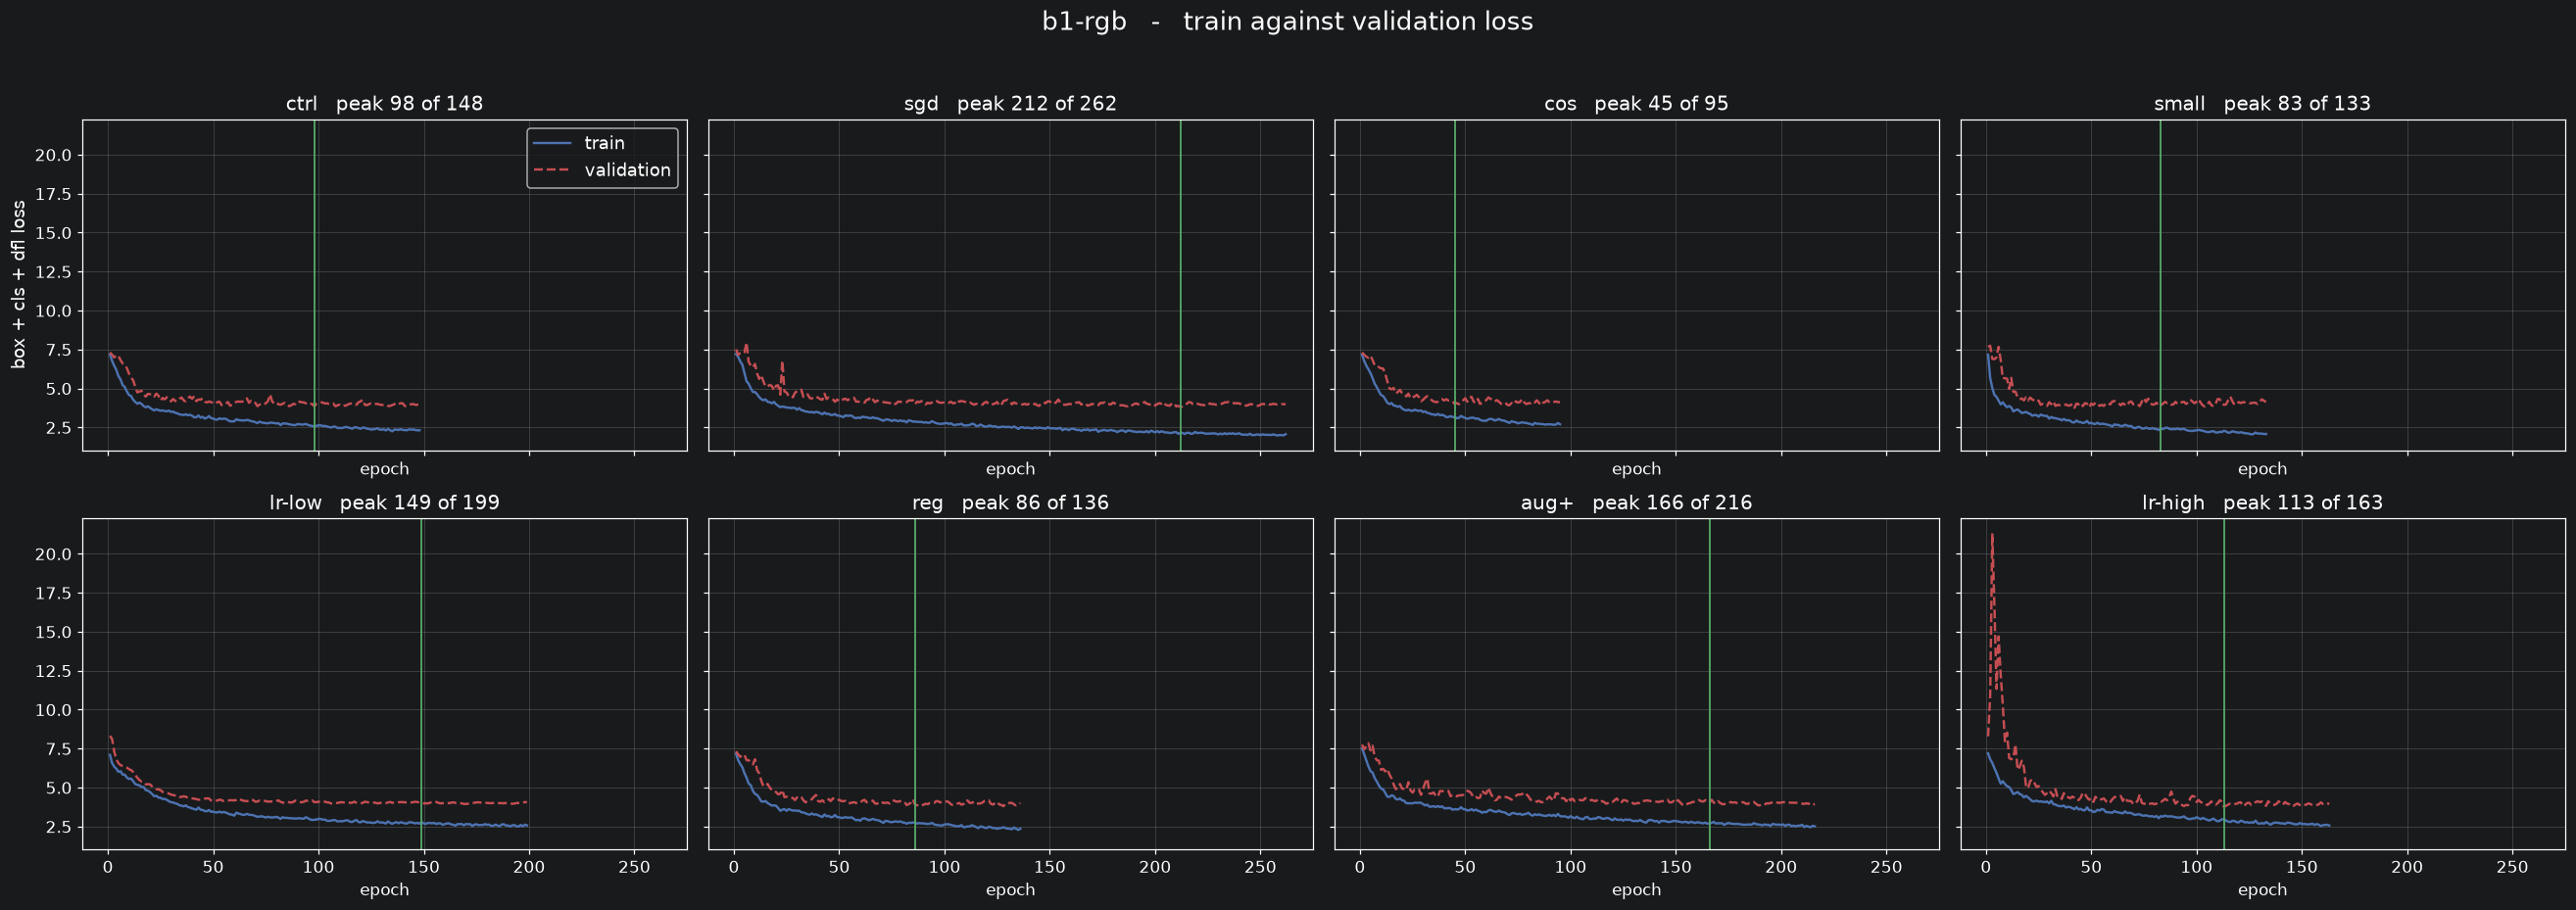

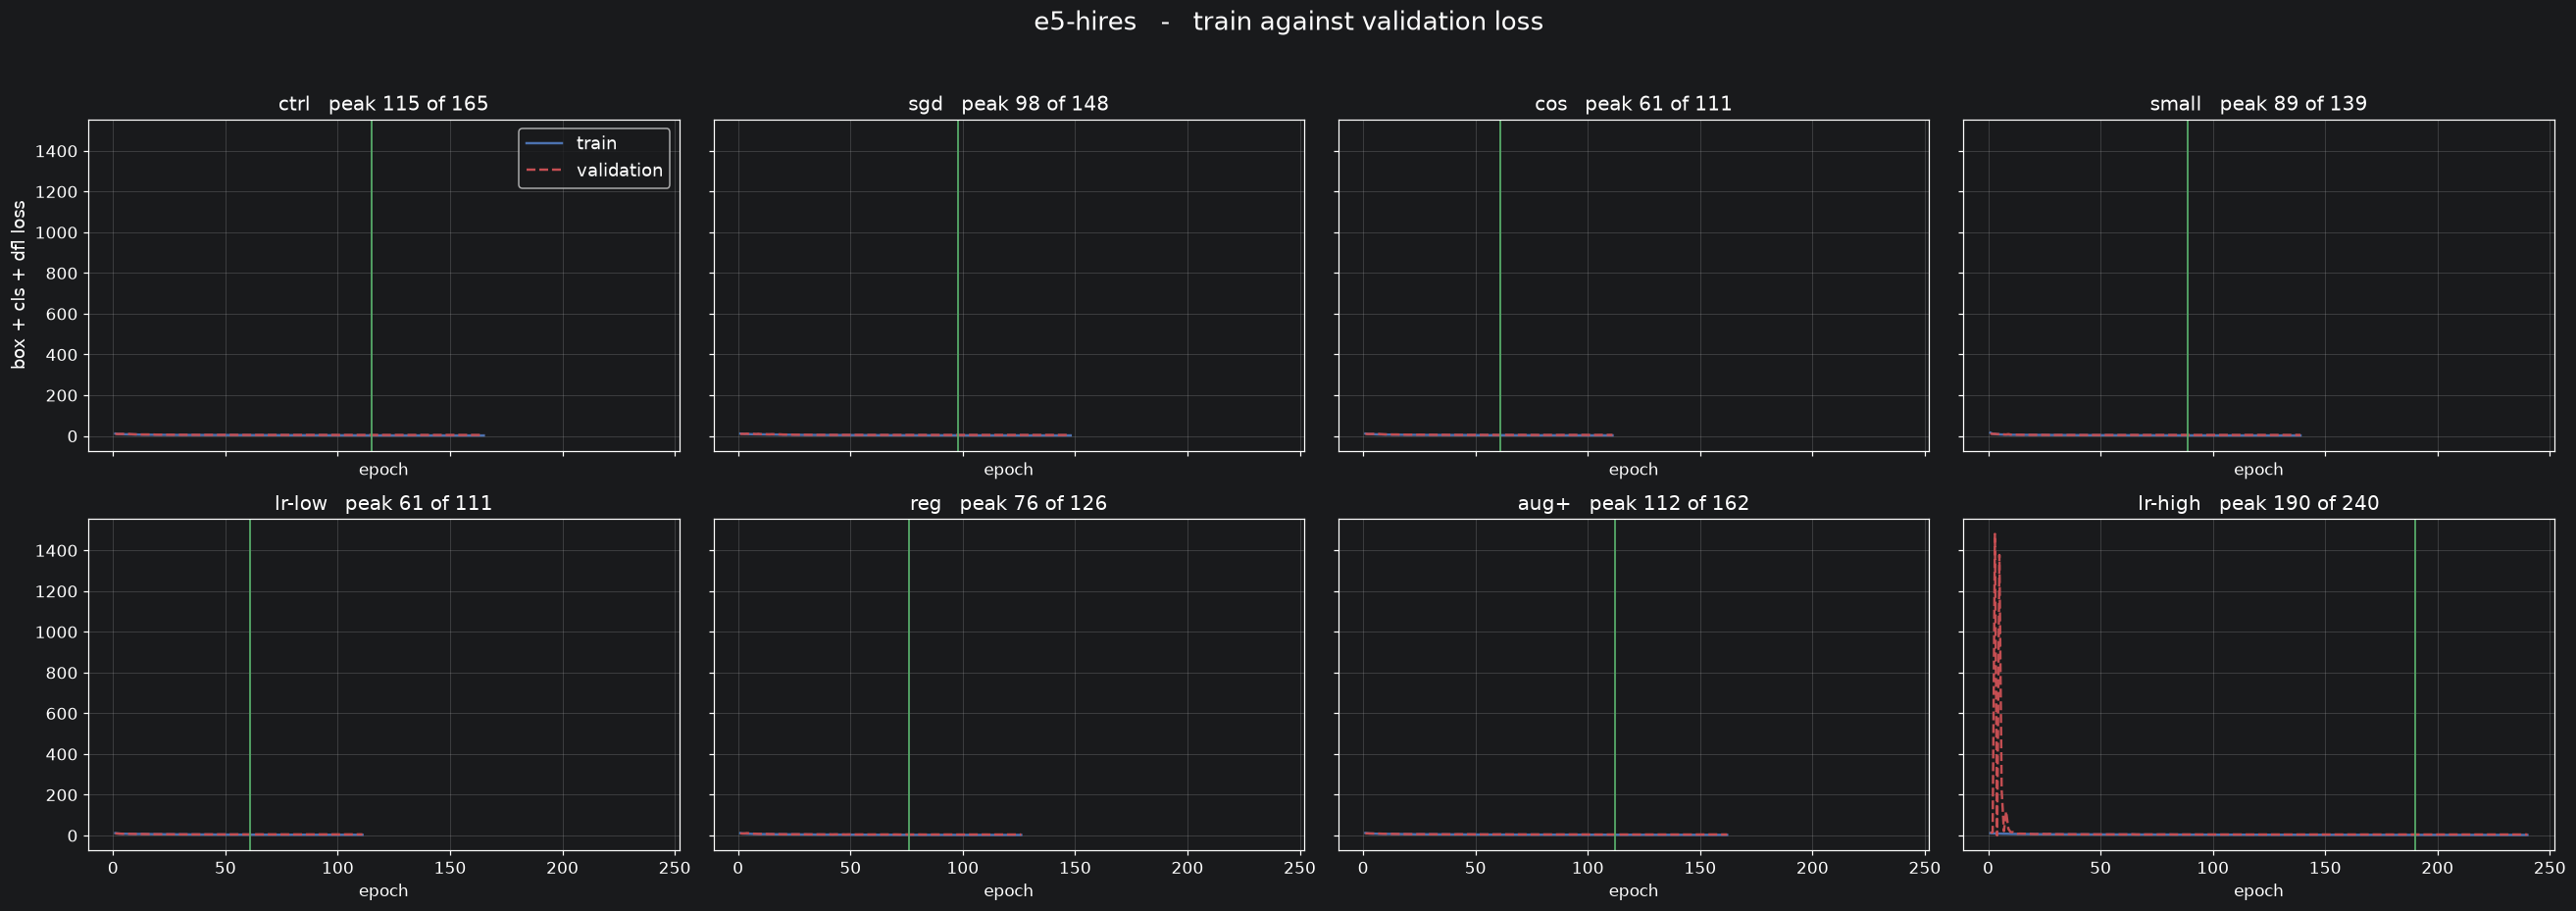

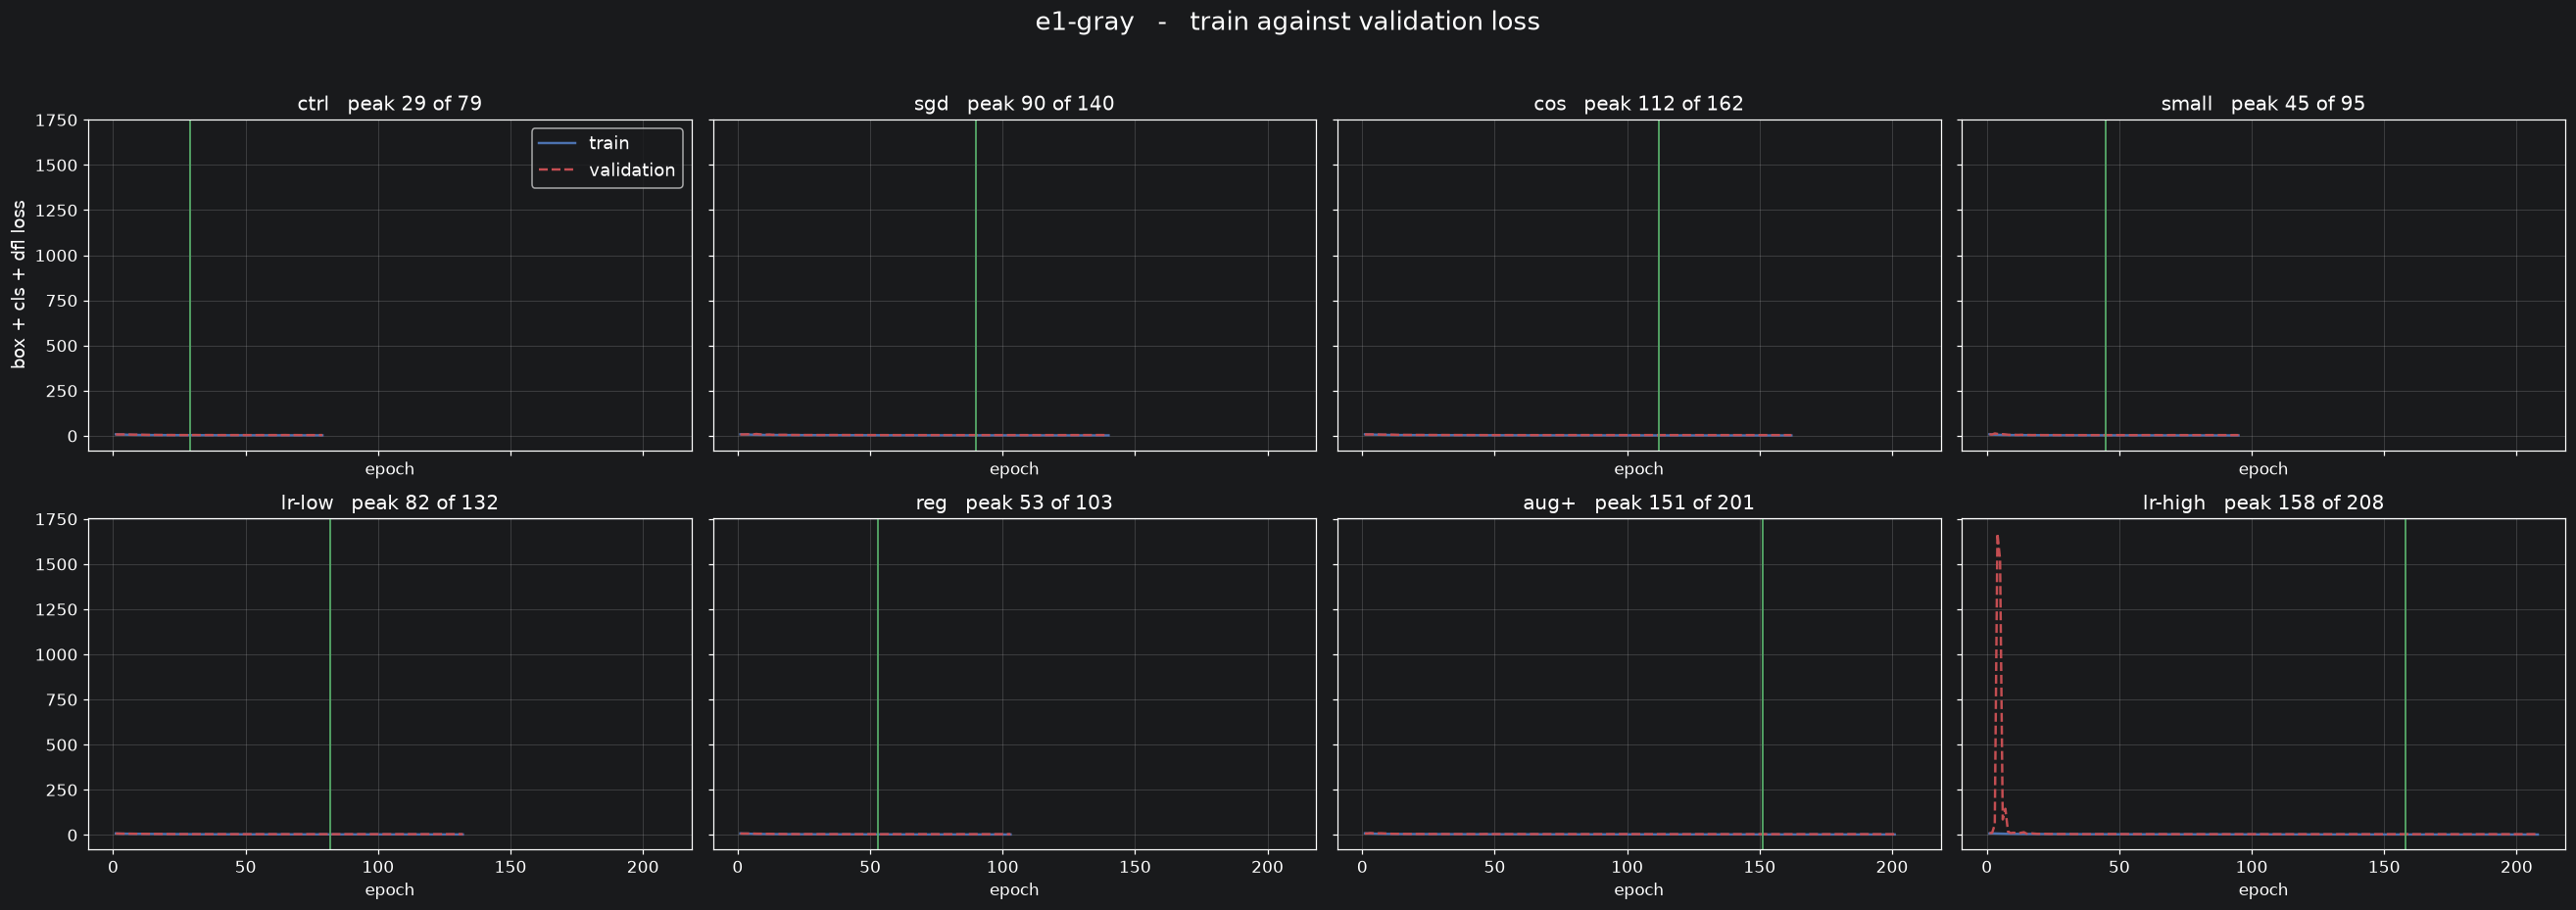

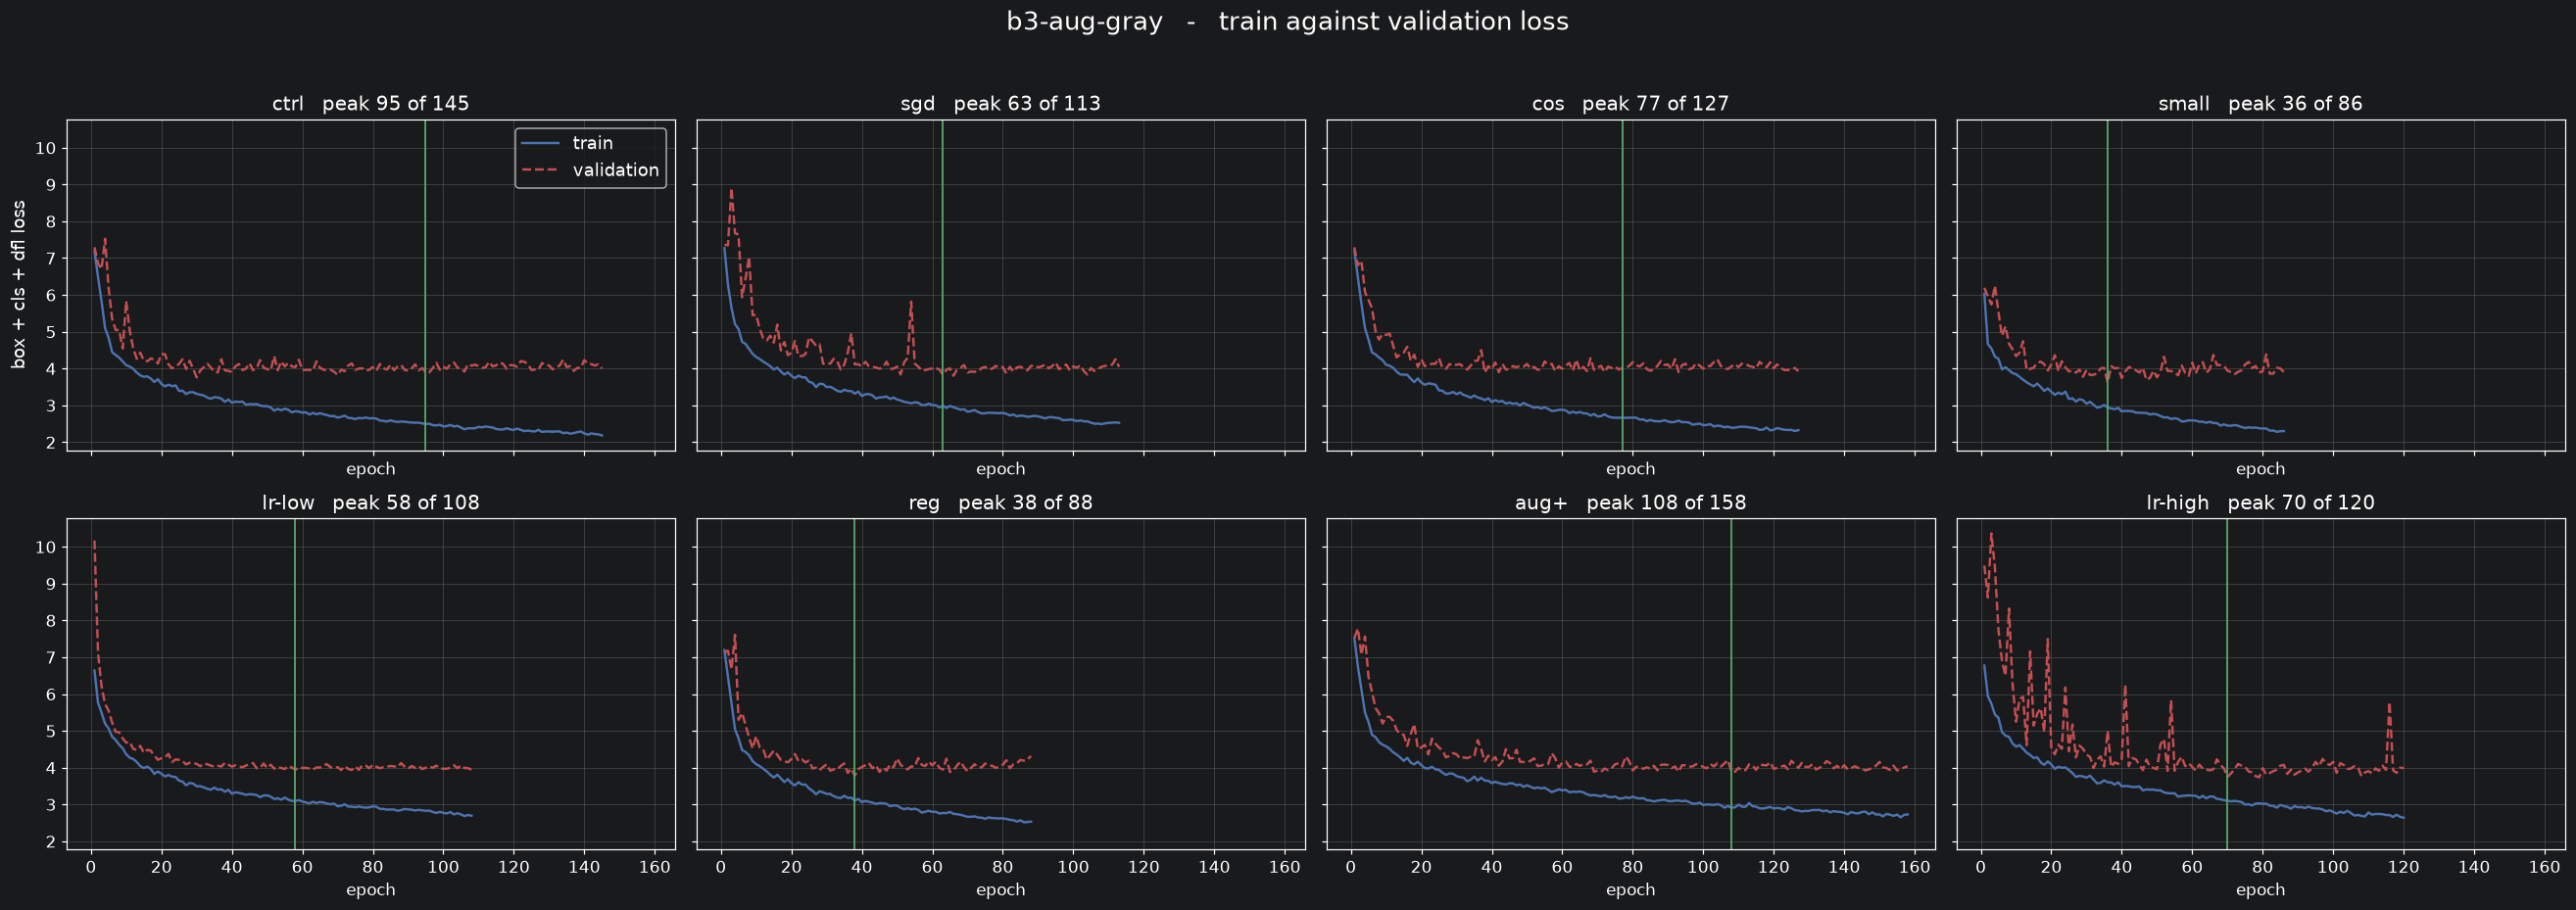

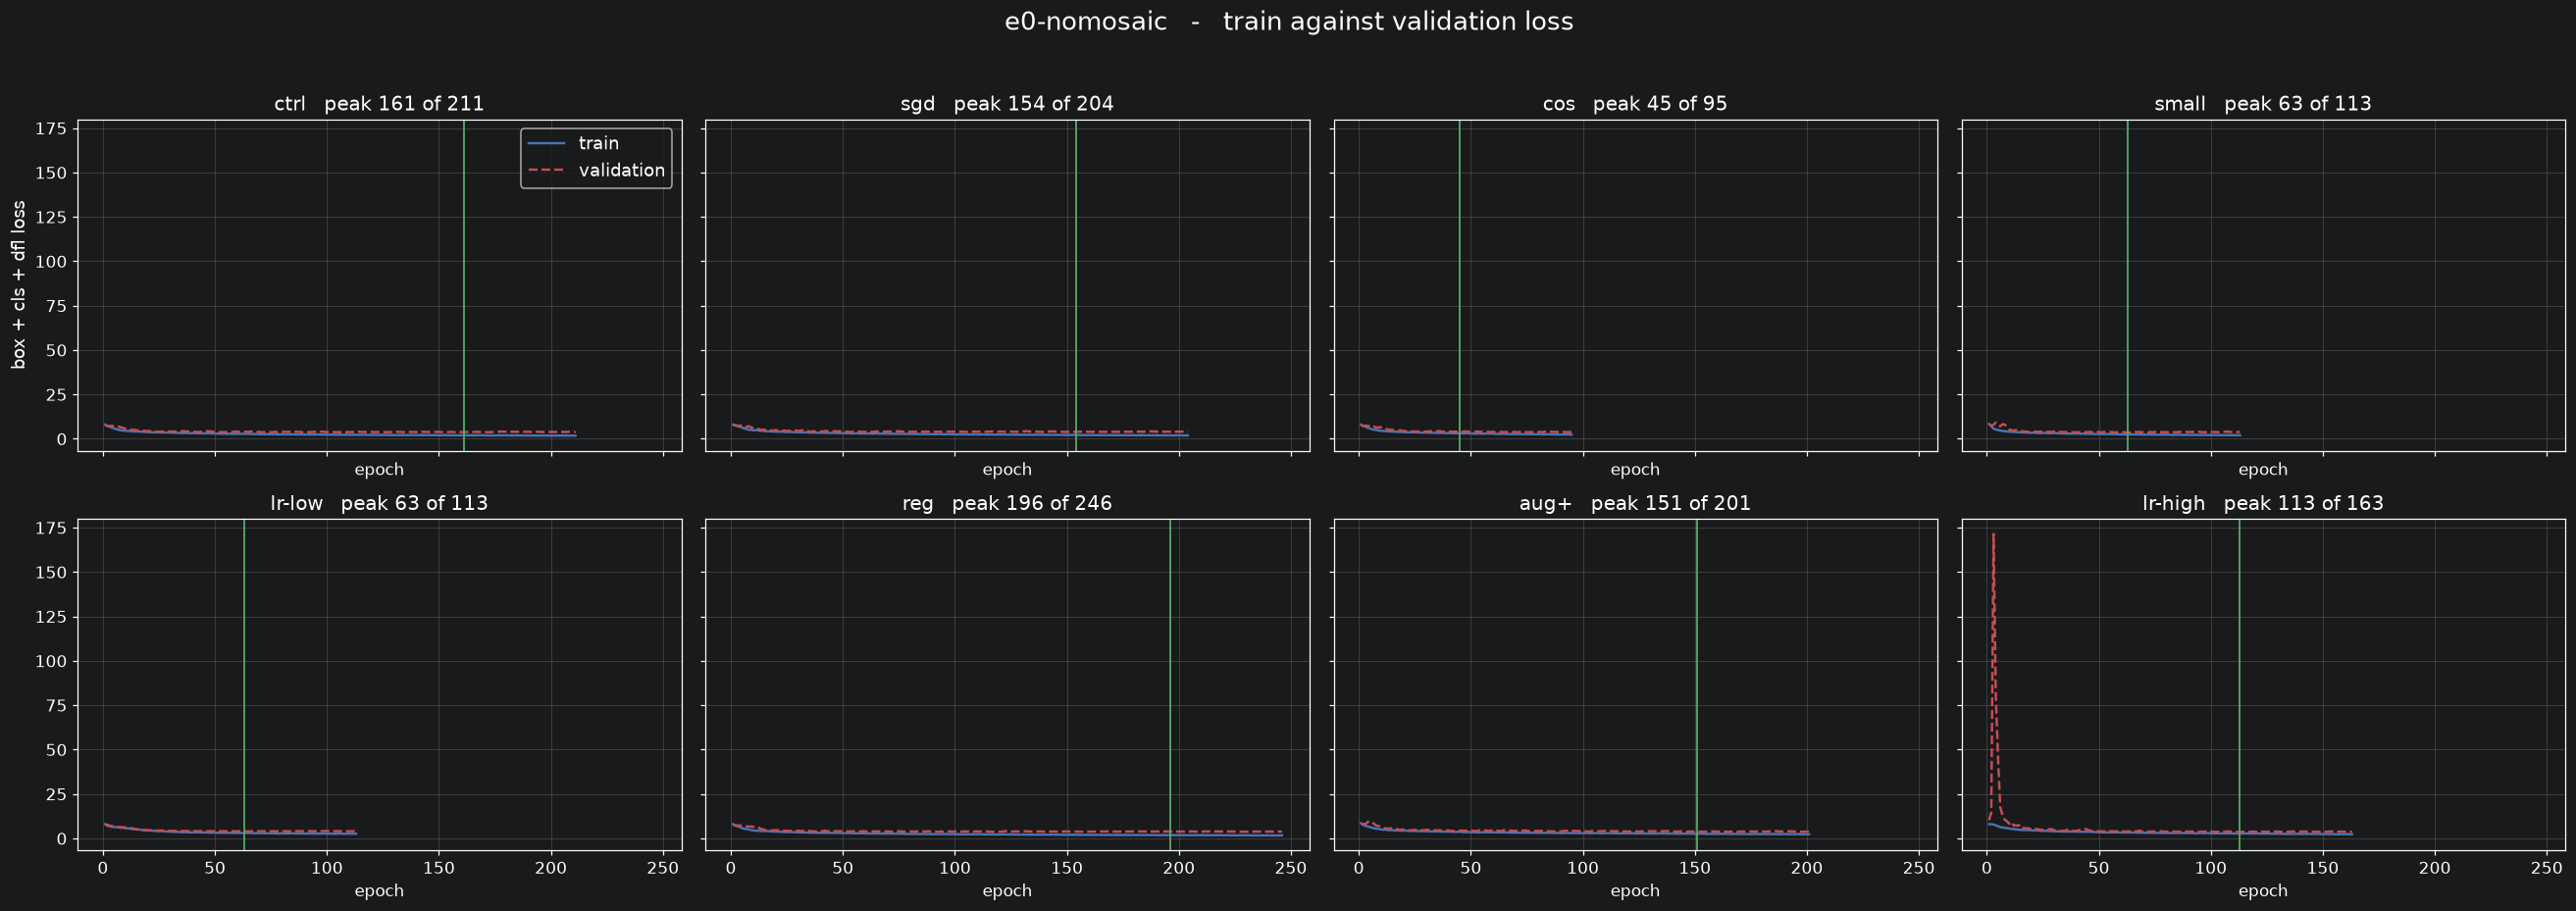

In [33]:
def loss_panel(ax, rec):
    df = history(rec)
    train, val = loss_pair(df)
    peak = best_epoch(df)
    ax.plot(df.epoch, train, color=TRAIN, lw=1.6, label="train")
    ax.plot(df.epoch, val, color=VAL, lw=1.6, ls="--", label="validation")
    ax.axvline(peak, color=PEAK, lw=1.2)
    ax.set_title(f"{rec['variant']}   peak {peak} of {int(df.epoch.max())}", fontsize=13)
    ax.tick_params(labelsize=11)
    ax.set_xlabel("epoch", fontsize=11)


for base in bases:
    present = [v for v in variants if (base, v) in found]
    if not present:
        continue
    cols = 4
    rows = -(-len(present) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6.0 * cols, 4.2 * rows), sharex=True, sharey=True)
    flat = np.atleast_1d(axes).ravel()

    for ax, v in zip(flat, present):
        loss_panel(ax, found[(base, v)])
    for ax in flat[len(present):]:
        ax.axis("off")

    flat[0].set_ylabel("box + cls + dfl loss", fontsize=12)
    flat[0].legend(fontsize=12)
    fig.suptitle(f"{base}   -   train against validation loss", fontsize=17, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### 5.2 validation mAP50-95, one figure per base

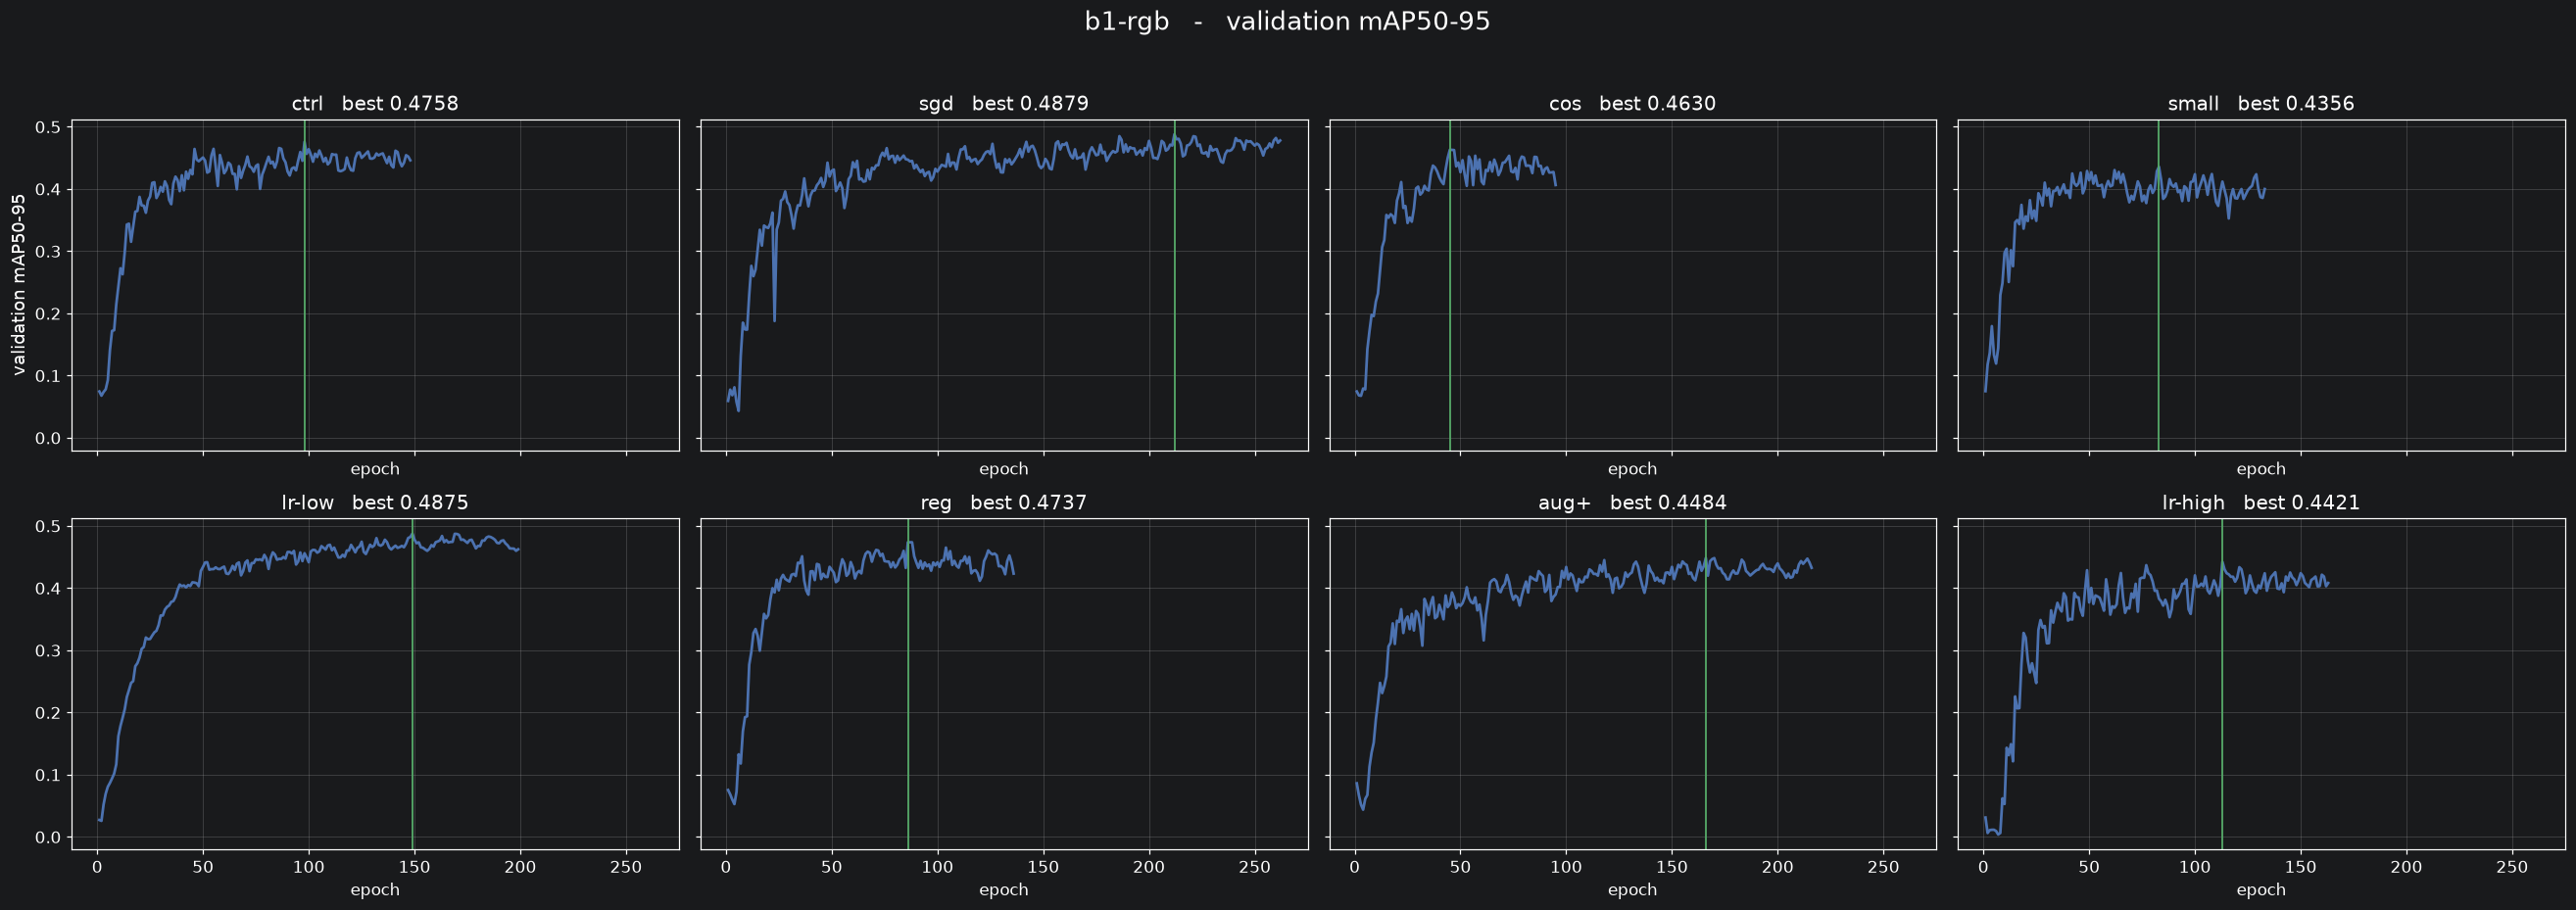

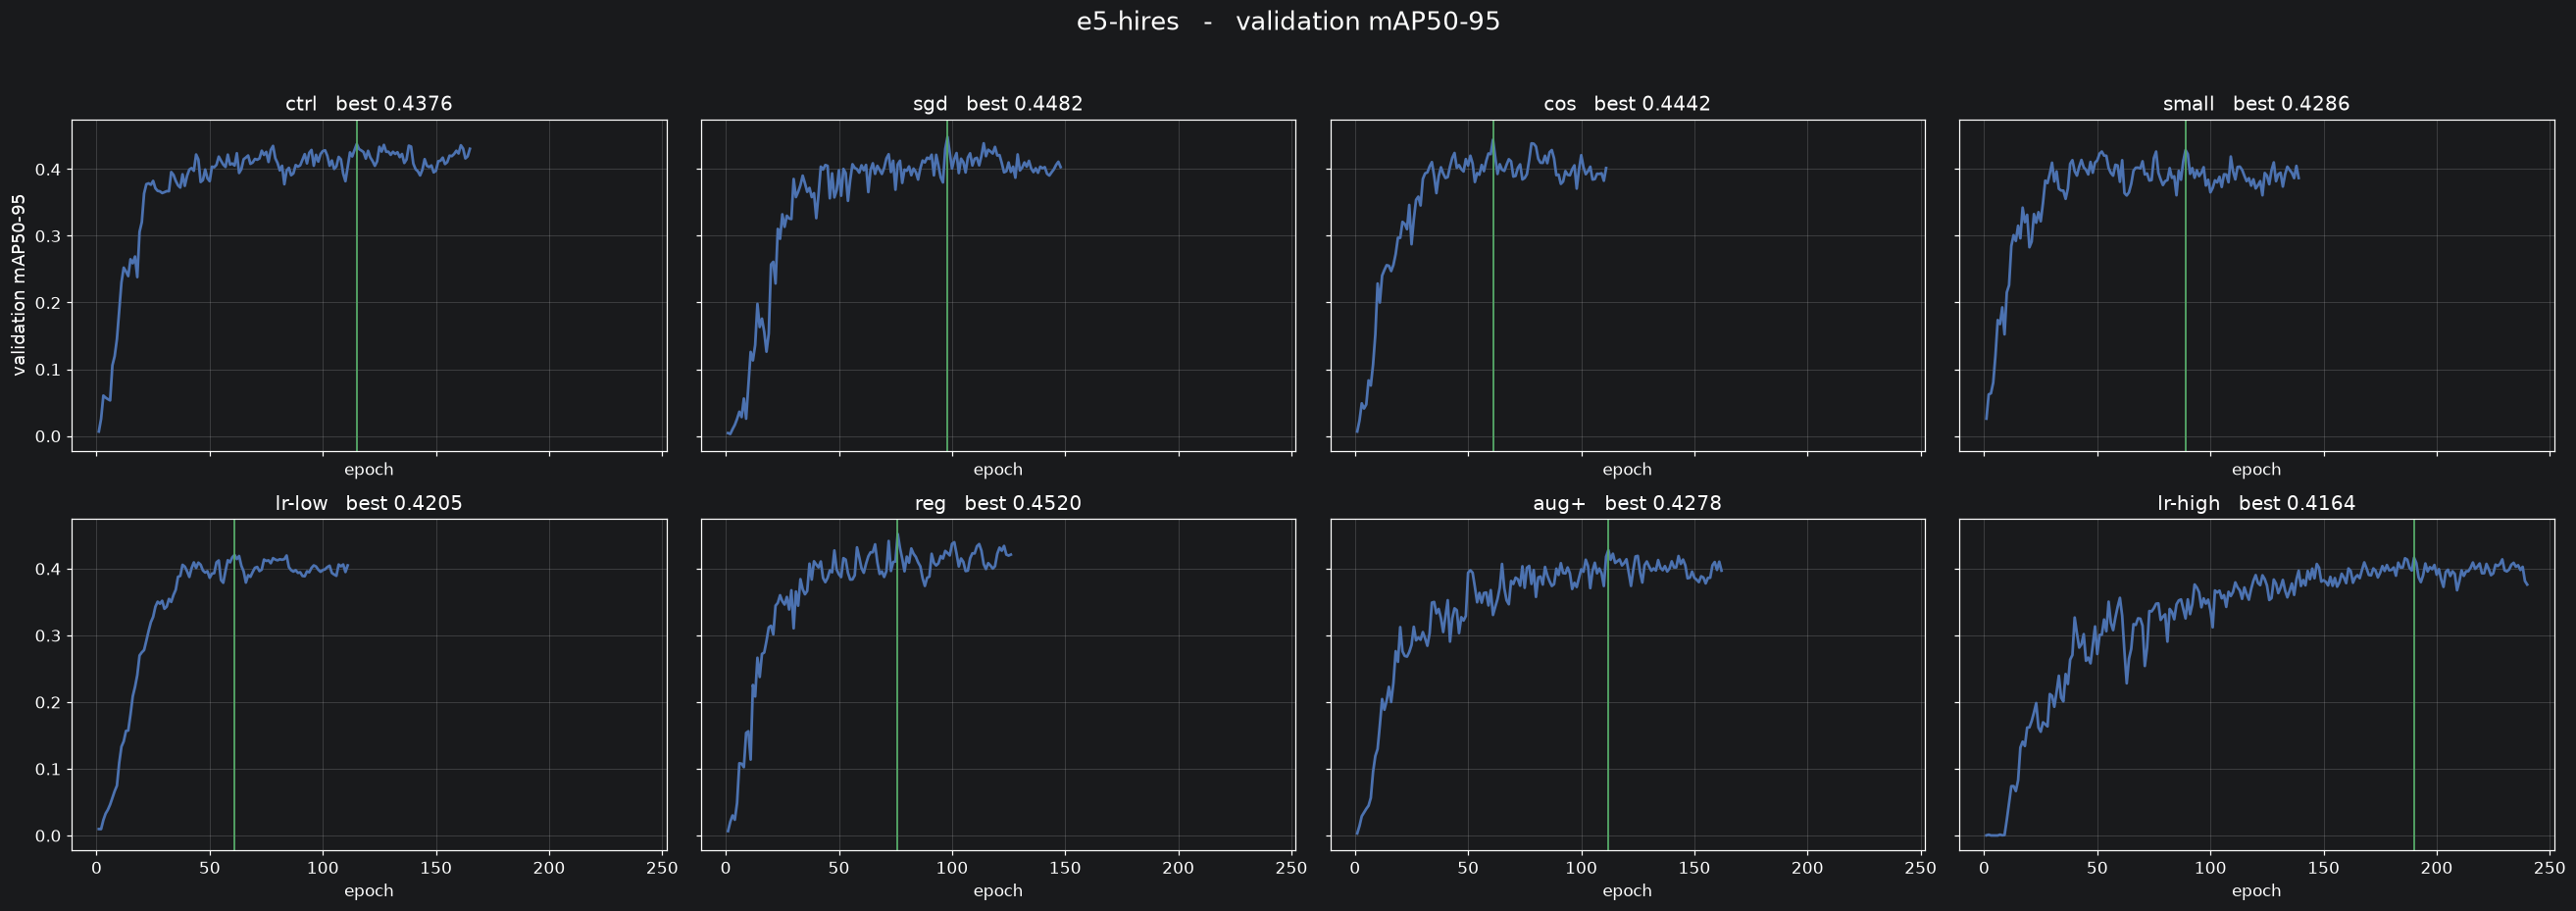

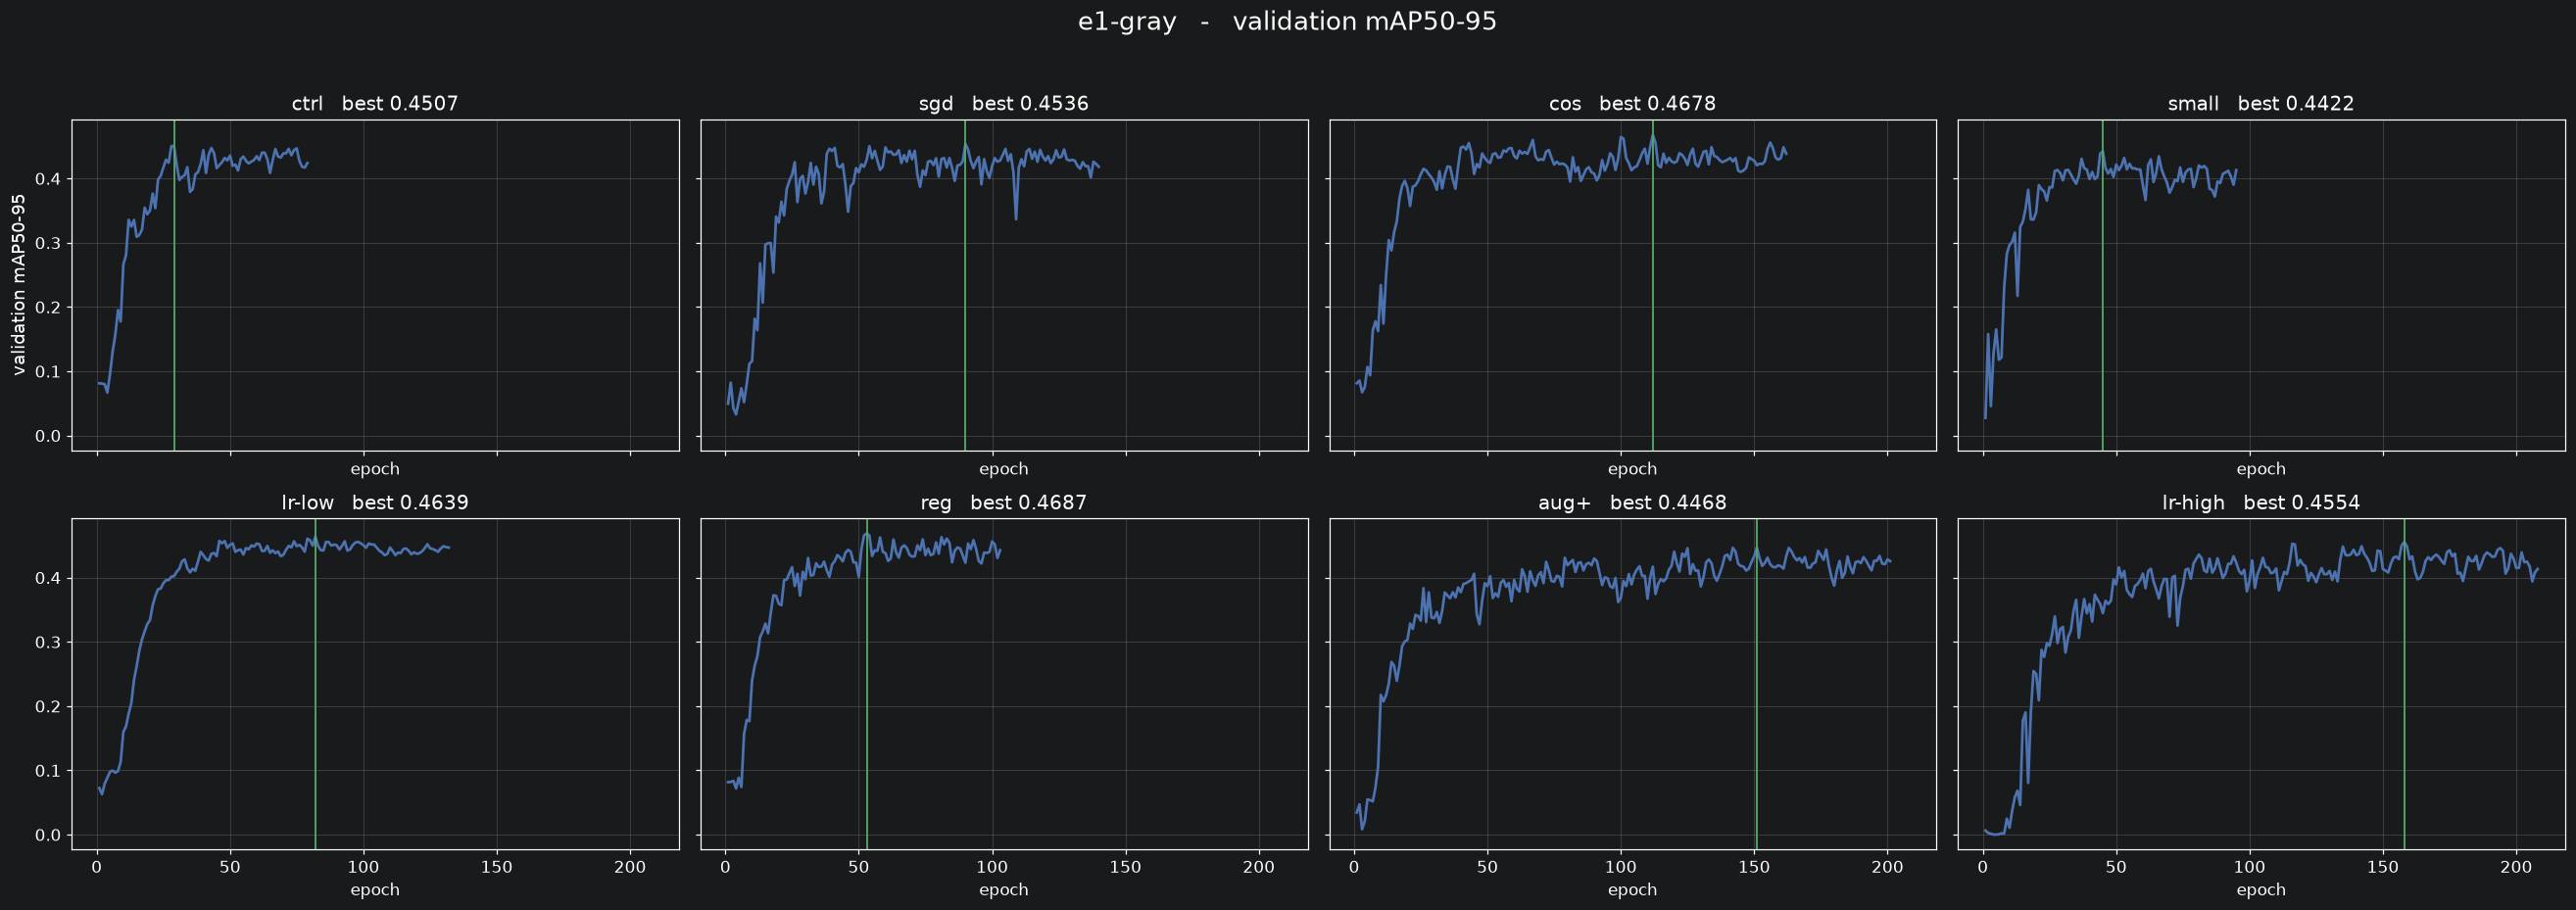

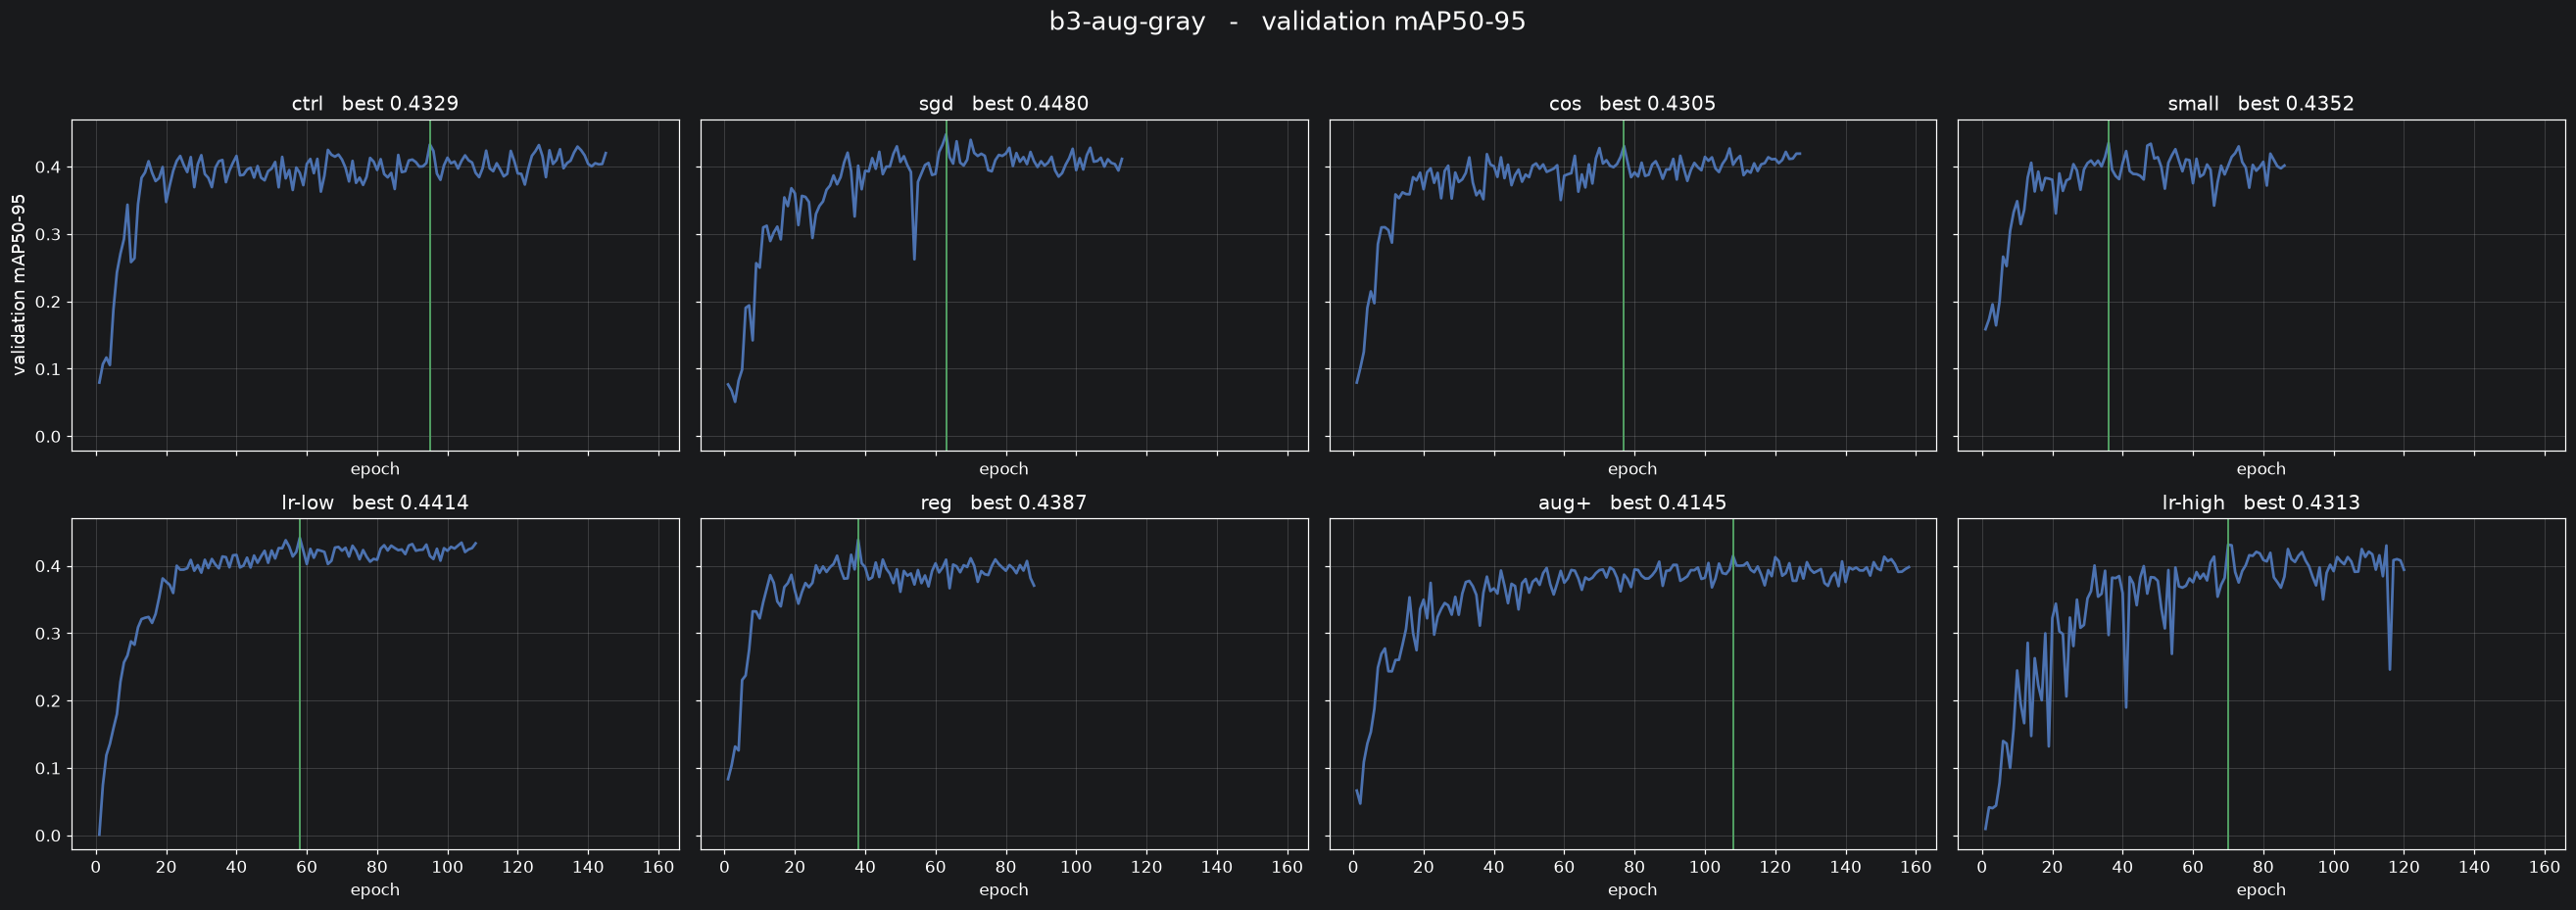

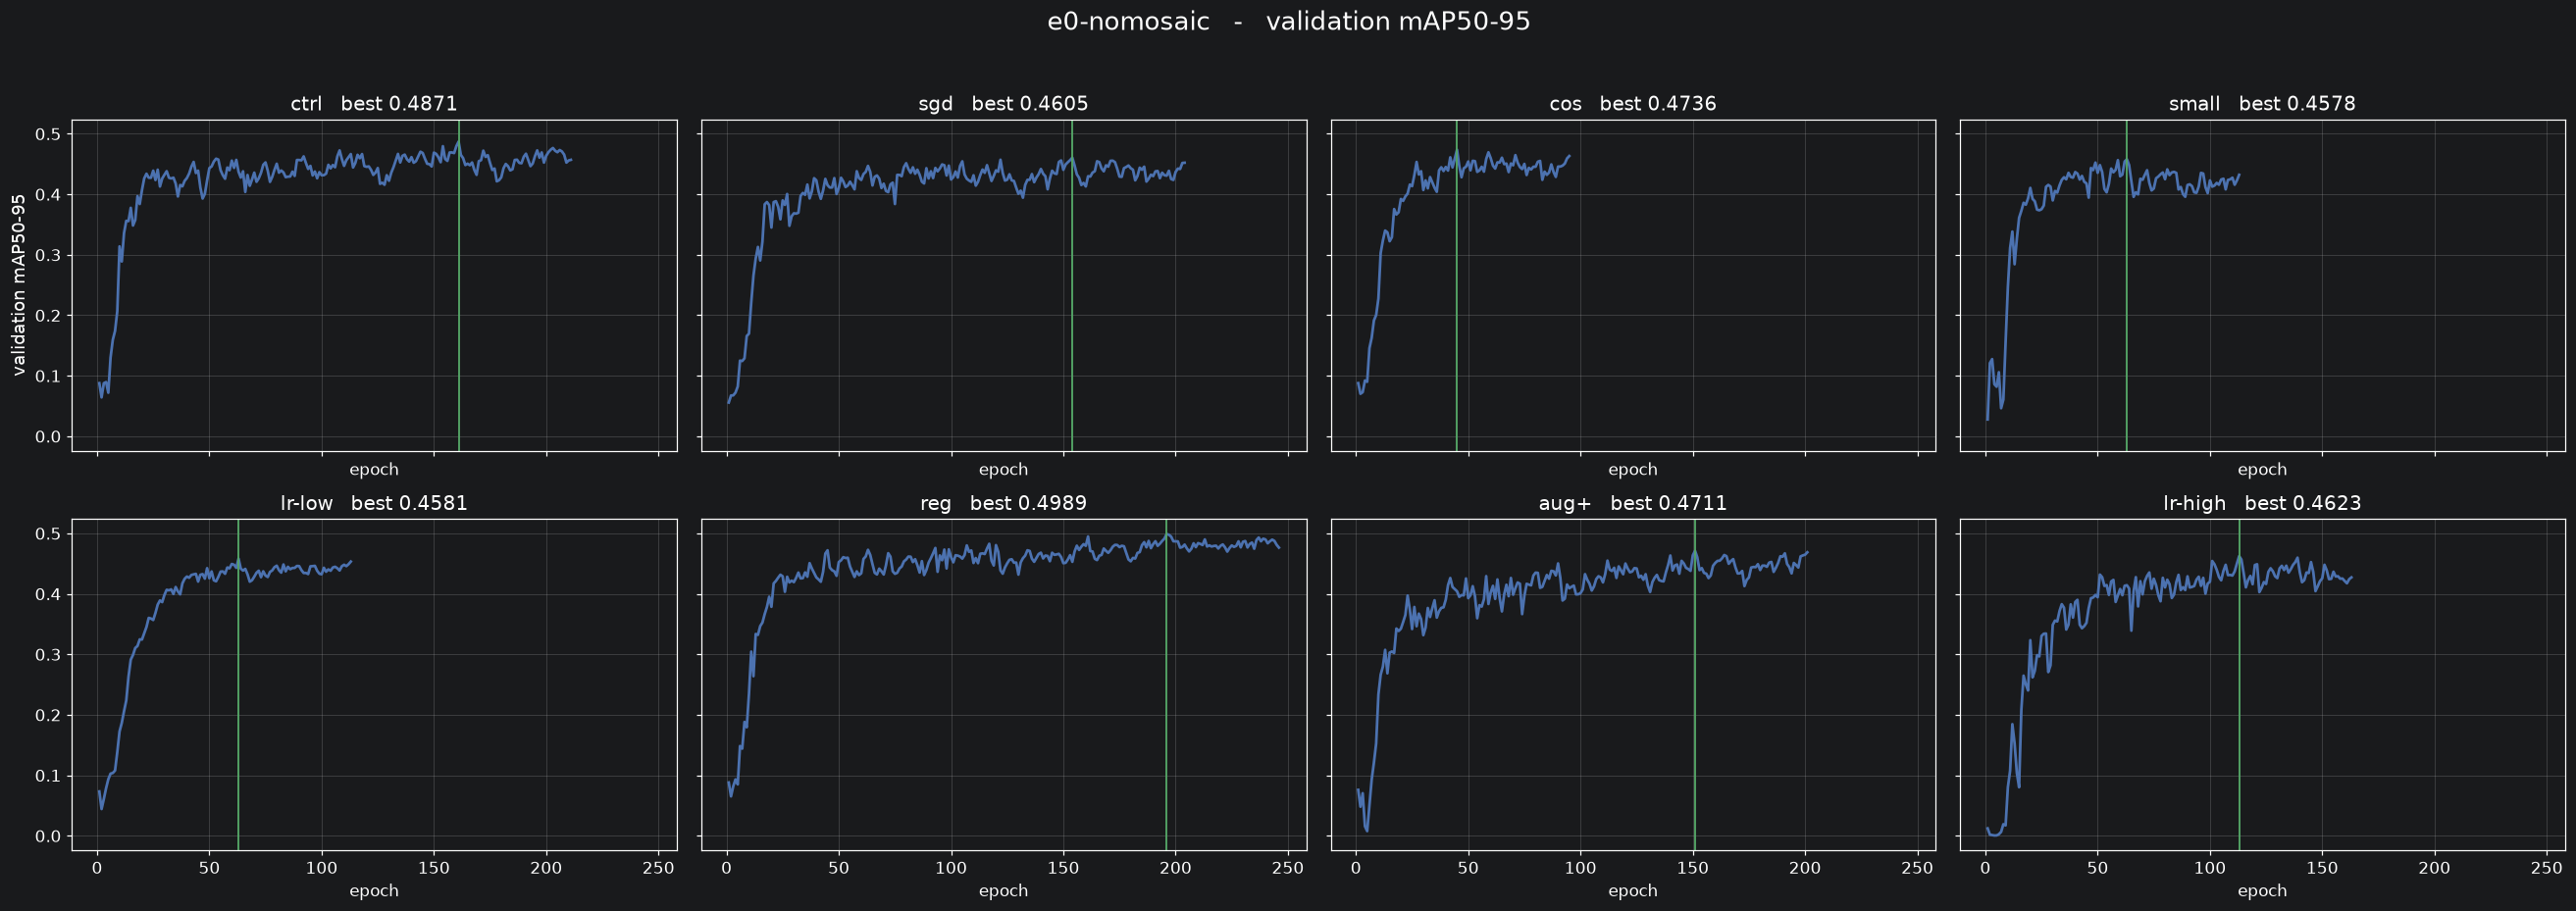

In [34]:
for base in bases:
    present = [v for v in variants if (base, v) in found]
    if not present:
        continue
    cols = 4
    rows = -(-len(present) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6.0 * cols, 4.2 * rows), sharex=True, sharey=True)
    flat = np.atleast_1d(axes).ravel()

    for ax, v in zip(flat, present):
        rec = found[(base, v)]
        df = history(rec)
        ax.plot(df.epoch, df[map_col(df)], color=TRAIN, lw=1.8)
        ax.axvline(best_epoch(df), color=PEAK, lw=1.2)
        ax.set_title(f"{v}   best {df[map_col(df)].max():.4f}", fontsize=13)
        ax.tick_params(labelsize=11)
        ax.set_xlabel("epoch", fontsize=11)
    for ax in flat[len(present):]:
        ax.axis("off")

    flat[0].set_ylabel("validation mAP50-95", fontsize=12)
    fig.suptitle(f"{base}   -   validation mAP50-95", fontsize=17, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### 5.3 convergence summary

In [21]:
rows_out = []
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    rows_out.append({"base": rec["base"], "variant": rec["variant"],
                     "epochs_run": int(df.epoch.max()), "best_epoch": best_epoch(df),
                     "val_mAP": round(float(df[map_col(df)].max()), 4),
                     "train_loss_end": round(float(train.iloc[-1]), 3),
                     "val_loss_best": round(float(val.min()), 3),
                     "val_loss_end": round(float(val.iloc[-1]), 3)})

curves = pd.DataFrame(rows_out)
curves["rebound"] = (curves.val_loss_end - curves.val_loss_best).round(3)
curves["headroom"] = (curves.best_epoch / curves.epochs_run).round(2)
curves.set_index(["base", "variant"]).sort_values("val_mAP", ascending=False)

epochs_run  best_epoch  val_mAP  train_loss_end  val_loss_best  val_loss_end  rebound  headroom
base        variant                                                                                                 
e0-nomosaic reg             246         196   0.4989           1.674          3.651         3.817    0.166      0.80
b1-rgb      sgd             262         212   0.4879           2.066          3.824         3.987    0.163      0.81
            lr-low          199         149   0.4875           2.572          3.941         4.058    0.117      0.75
e0-nomosaic ctrl            211         161   0.4871           1.804          3.658         3.897    0.239      0.76
b1-rgb      ctrl            148          98   0.4758           2.315          3.856         3.936    0.080      0.66
            reg             136          86   0.4737           2.360          3.802         4.007    0.205      0.63
e0-nomosaic cos              95          45   0.4736           2.389          3.703         3.703    0.000      0.47
            aug+            201         151   0.4711           2.299          3.603         3.815    0.212      0.75
e1-gray     reg             103          53   0.4687           2.361          3.755         3.947    0.192      0.51
            cos             162         112   0.4678           1.924          3.688         3.905    0.217      0.69
            lr-low          132          82   0.4639           2.447          3.917         4.003    0.086      0.62
b1-rgb      cos              95          45   0.4630           2.700          3.926         4.119    0.193      0.47
e0-nomosaic lr-high         163         113   0.4623           2.350          3.612         3.737    0.125      0.69
            sgd             204         154   0.4605           1.876          3.832         3.934    0.102      0.75
            lr-low          113          63   0.4581           2.546          3.945         4.023    0.078      0.56
            small           113          63   0.4578           1.983          3.536         3.824    0.288      0.56
e1-gray     lr-high         208         158   0.4554           2.086          3.588         3.887    0.299      0.76
            sgd             140          90   0.4536           2.220          3.805         4.013    0.208      0.64
e5-hires    reg             126          76   0.4520           2.548          4.505         4.608    0.103      0.60
e1-gray     ctrl             79          29   0.4507           2.527          3.866         4.172    0.306      0.37
b1-rgb      aug+            216         166   0.4484           2.512          3.862         3.943    0.081      0.77
e5-hires    sgd             148          98   0.4482           2.353          4.457         4.618    0.161      0.66
b3-aug-gray sgd             113          63   0.4480           2.526          3.804         4.044    0.240      0.56
e1-gray     aug+            201         151   0.4468           2.341          3.809         3.898    0.089      0.75
e5-hires    cos             111          61   0.4442           2.602          4.576         4.951    0.375      0.55
e1-gray     small            95          45   0.4422           2.117          3.692         3.797    0.105      0.47
b1-rgb      lr-high         163         113   0.4421           2.565          3.771         3.938    0.167      0.69
b3-aug-gray lr-low          108          58   0.4414           2.695          3.934         3.945    0.011      0.54
            reg              88          38   0.4387           2.533          3.782         4.316    0.534      0.43
e5-hires    ctrl            165         115   0.4376           2.089          4.498         4.550    0.052      0.70
b1-rgb      small           133          83   0.4356           2.080          3.756         4.136    0.380      0.62
b3-aug-gray small            86          36   0.4352           2.300          3.618         3.904    0.286      0.42
            ctrl            145          95

## 6. results

In [22]:
def evaluate(rec):
    m = YOLO(rec["best"]).val(data=str(detect / rec["data"] / "data.yaml"), split="test",
                              imgsz=rec["imgsz"], batch=rec["batch"], device=device, project=str(project),
                              name=f"{rec['run']}-test", exist_ok=True, plots=True)
    out = dict(rec)
    out.update({"mAP50": round(float(m.box.map50), 4), "mAP50_95": round(float(m.box.map), 4),
                "precision": round(float(m.box.mp), 4), "recall": round(float(m.box.mr), 4),
                "val_dir": str(m.save_dir)})
    return out, m


tested, models = [], {}
for rec in records:
    out, m = evaluate(rec)
    tested.append(out)
    models[rec["run"]] = m

compare = pd.DataFrame(tested).set_index("run")[
    ["base", "variant", "data", "imgsz", "optimizer", "lr0", "minutes",
     "mAP50", "mAP50_95", "precision", "recall"]]
compare.sort_values("mAP50_95", ascending=False)

Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 3.51.8 MB/s, size: 56.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\test\labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.3s7.1s
                   all         28        140      0.628      0.815      0.767      0.409
                 Camel         28         28      0.935          1      0.992      0.804
          High_withers         13         13      0.554          1      0.875      0.384
            Large-hea

,base,variant,data,imgsz,optimizer,lr0,minutes,mAP50,mAP50_95,precision,recall
run,,,,,,,,,,,
e1-gray--aug+,e1-gray,aug+,gray,640,auto,NaN,6.7,0.8113,0.4501,0.7658,0.8271
b1-rgb--aug+,b1-rgb,aug+,plain,640,auto,NaN,7.2,0.8323,0.4484,0.7757,0.7625
b1-rgb--lr-low,b1-rgb,lr-low,plain,640,AdamW,0.0001,6.7,0.7660,0.4473,0.7260,0.7719
e0-nomosaic--sgd,e0-nomosaic,sgd,plain,640,SGD,0.0100,6.5,0.7646,0.4473,0.7363,0.7612
e5-hires--aug+,e5-hires,aug+,plain,1280,auto,NaN,17.1,0.7721,0.4378,0.7532,0.6662
b1-rgb--sgd,b1-rgb,sgd,plain,640,SGD,0.0100,8.3,0.7529,0.4371,0.6941,0.7813
e1-gray--reg,e1-gray,reg,gray,640,auto,NaN,3.6,0.7620,0.4250,0.7260,0.7100
e1-gray--sgd,e1-gray,sgd,gray,640,SGD,0.0100,4.5,0.7519,0.4242,0.7153,0.7198
b3-aug-gray--aug+,b3-aug-gray,aug+,rot90-gray,640,auto,NaN,15.5,0.7740,0.4227,0.7315,0.7681


### 6.1 variant against base

In [23]:
grid = compare.pivot_table(index="base", columns="variant", values="mAP50_95")
grid = grid[[v for v in variants if v in grid.columns]]
grid["v2_original"] = [prev.loc[b, "mAP50_95"] for b in grid.index]
grid["best_variant"] = grid[[v for v in variants if v in grid.columns]].idxmax(axis=1)
grid["gain"] = (grid[[v for v in variants if v in grid.columns]].max(axis=1) - grid.v2_original).round(4)
grid.round(4).sort_values("gain", ascending=False)

variant,ctrl,sgd,cos,small,lr-low,reg,aug+,lr-high,v2_original,best_variant,gain
base,,,,,,,,,,,
e0-nomosaic,0.4176,0.4473,0.4208,0.4226,0.4215,0.4110,0.4167,0.3930,0.4107,sgd,0.0366
e1-gray,0.3828,0.4242,0.3974,0.4056,0.3875,0.4250,0.4501,0.4033,0.4259,aug+,0.0242
e5-hires,0.4096,0.4103,0.3784,0.3812,0.3702,0.3811,0.4378,0.3834,0.4261,aug+,0.0117
b1-rgb,0.4089,0.4371,0.4158,0.4136,0.4473,0.4035,0.4484,0.4206,0.4384,aug+,0.0100
b3-aug-gray,0.3901,0.3689,0.3537,0.3921,0.3826,0.3937,0.4227,0.3596,0.4164,aug+,0.0063


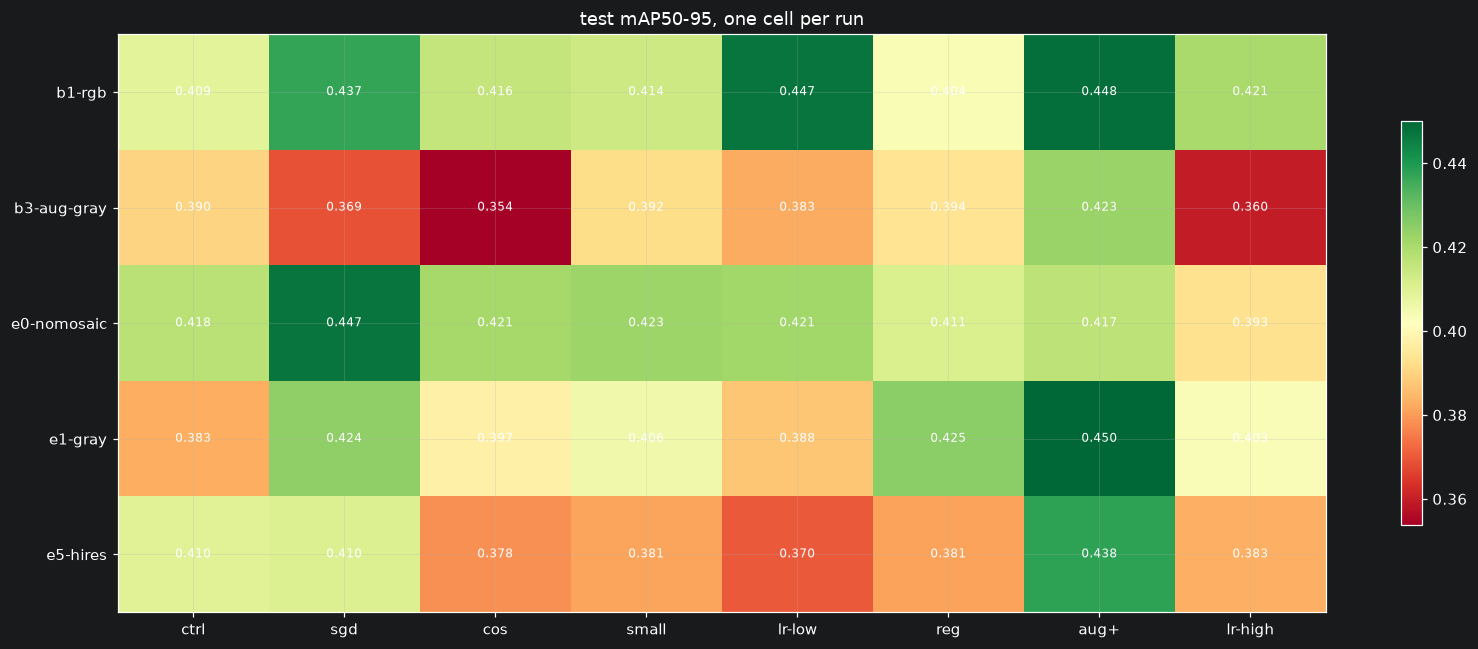

In [24]:
cols = [v for v in variants if v in grid.columns]
vals = grid[cols].astype(float)

fig, ax = plt.subplots(figsize=(1.5 * len(cols) + 3, 0.8 * len(vals) + 2))
im = ax.imshow(vals.values, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(cols)), cols)
ax.set_yticks(range(len(vals)), vals.index)
for r in range(len(vals)):
    for c in range(len(cols)):
        v = vals.values[r, c]
        if pd.notna(v):
            ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=8)

ax.set_title("test mAP50-95, one cell per run")
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

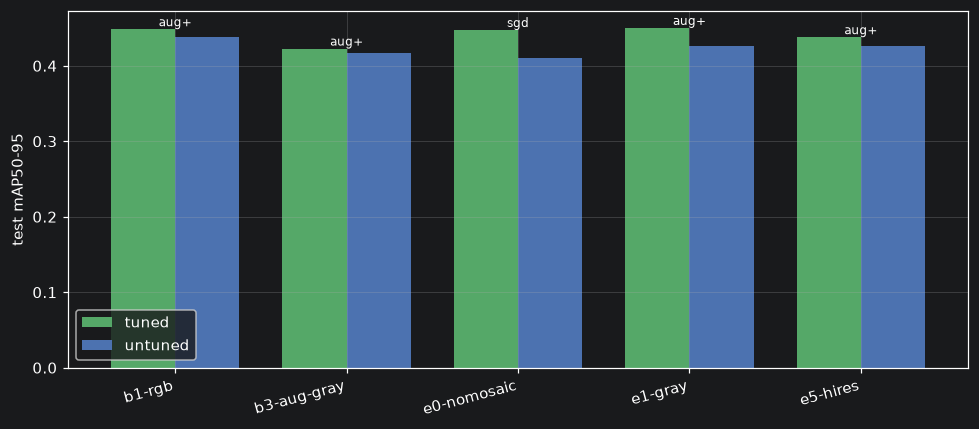

In [25]:
best_per_base = pd.DataFrame({
    "tuned": vals.max(axis=1),
    "untuned": grid.v2_original.astype(float),
})

fig, ax = plt.subplots(figsize=(9, 4))
best_per_base.plot(kind="bar", ax=ax, color=["#55a868", "#4c72b0"], width=0.75)
ax.set_ylabel("test mAP50-95")
ax.set_xlabel("")
for r, (b, row) in enumerate(best_per_base.iterrows()):
    ax.text(r, max(row) + 0.004, grid.loc[b, "best_variant"], ha="center", fontsize=8)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### 6.2 variant means

In [26]:
by_variant = compare.groupby("variant").mAP50_95.agg(["mean", "max", "count"]).round(4)
by_variant["vs_ctrl"] = (by_variant["mean"] - by_variant.loc["ctrl", "mean"]).round(4)
by_variant.reindex([v for v in variants if v in by_variant.index])

,mean,max,count,vs_ctrl
variant,,,,
ctrl,0.4018,0.4176,5,0.0000
sgd,0.4176,0.4473,5,0.0158
cos,0.3932,0.4208,5,-0.0086
small,0.4030,0.4226,5,0.0012
lr-low,0.4018,0.4473,5,0.0000
reg,0.4029,0.4250,5,0.0011
aug+,0.4351,0.4501,5,0.0333
lr-high,0.3920,0.4206,5,-0.0098


### 6.3 per-class, best run

In [27]:
def per_class(m):
    rows = []
    for i, c in enumerate(list(m.box.ap_class_index)):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({"cls": canon[int(c)], "precision": round(float(p), 3), "recall": round(float(r), 3),
                     "mAP50": round(float(ap50), 3), "mAP50_95": round(float(ap), 3)})
    return pd.DataFrame(rows).set_index("cls").reindex(canon)


winner = compare.mAP50_95.idxmax()
pc = per_class(models[winner])
print(f"winner: {winner}   mAP50-95 {compare.loc[winner, 'mAP50_95']}   "
      f"against {prev.mAP50_95.max():.4f} for the best untuned v2 run")
pc

winner: e1-gray--aug+   mAP50-95 0.4501   against 0.4384 for the best untuned v2 run


,precision,recall,mAP50,mAP50_95
cls,,,,
Camel,0.930,1.000,0.994,0.813
High_withers,0.758,0.923,0.913,0.351
Large-head,0.776,0.771,0.740,0.490
Large-lips,0.961,0.929,0.983,0.447
Large-nose,0.907,0.752,0.899,0.414
Large_hump,0.672,0.846,0.639,0.345
Long-legs,0.572,0.750,0.673,0.341
Long-neck,0.766,0.780,0.849,0.546
Wide_body,0.549,0.692,0.612,0.303


### 6.4 winner diagnostics

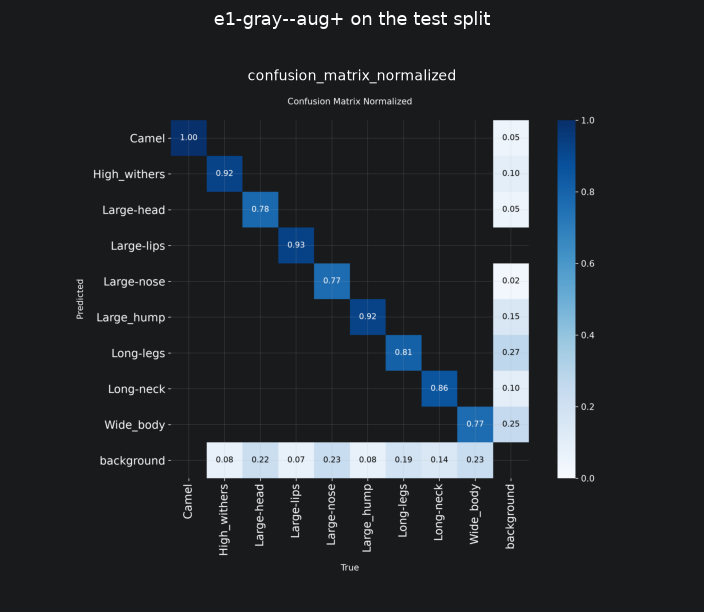

In [28]:
val_dir = pathlib.Path(next(r["val_dir"] for r in tested if r["run"] == winner))
shots = [f for f in ("confusion_matrix_normalized.png", "PR_curve.png", "R_curve.png")
         if (val_dir / f).exists()]

if not shots:
    print("no plots found, was val() run with plots=True?")
else:
    from PIL import Image
    fig, axes = plt.subplots(1, len(shots), figsize=(6.5 * len(shots), 6))
    for ax, f in zip(np.atleast_1d(axes), shots):
        ax.imshow(Image.open(val_dir / f))
        ax.set_title(f[:-4], fontsize=9)
        ax.axis("off")
        ax.grid(False)
    fig.suptitle(f"{winner} on the test split")
    plt.tight_layout()
    plt.show()

### 6.5 error analysis

In [29]:
def read_label(path):
    rows = []
    for line in pathlib.Path(path).read_text(encoding="utf-8").splitlines():
        if line.strip():
            p = line.split()
            rows.append((int(p[0]), [float(v) for v in p[1:]]))
    return rows


def iou(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, x1 - x0) * max(0.0, y1 - y0)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


win_rec = next(r for r in tested if r["run"] == winner)
model = YOLO(win_rec["best"])
root_dir = detect / win_rec["data"] / "test"

faults, per_image = [], []
for name in sorted(os.listdir(root_dir / "images")):
    lab = root_dir / "labels" / (os.path.splitext(name)[0] + ".txt")
    gt = [(c, [g[0] - g[2] / 2, g[1] - g[3] / 2, g[0] + g[2] / 2, g[1] + g[3] / 2])
          for c, g in read_label(lab)]

    r = model.predict(str(root_dir / "images" / name), conf=0.25, imgsz=win_rec["imgsz"],
                      device=device, verbose=False)[0]
    pred = sorted(((int(c), float(f), b) for c, f, b in
                   zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxyn.tolist())),
                  key=lambda d: -d[1])

    used, tp, fp = set(), 0, 0
    for cls, conf, box in pred:
        best_iou, hit = 0.0, None
        for k, (gc, gb) in enumerate(gt):
            if k in used or gc != cls:
                continue
            v = iou(box, gb)
            if v > best_iou:
                best_iou, hit = v, k
        if best_iou >= 0.5:
            used.add(hit); tp += 1
        else:
            fp += 1
            faults.append({"image": name, "fault": "false positive", "cls": canon[cls]})
    for k, (gc, _) in enumerate(gt):
        if k not in used:
            faults.append({"image": name, "fault": "missed", "cls": canon[gc]})
    per_image.append({"image": name, "boxes": len(gt), "tp": tp, "fp": fp, "fn": len(gt) - tp})

errors = pd.DataFrame(faults)
images = pd.DataFrame(per_image)
print(f"{winner}: {images.tp.sum()} correct, {images.fp.sum()} false positives, {images.fn.sum()} missed")
errors.groupby(["cls", "fault"]).size().unstack(fill_value=0).reindex(canon).fillna(0).astype(int)

e1-gray--aug+: 120 correct, 42 false positives, 20 missed


fault,false positive,missed
cls,,
Camel,1,0
High_withers,4,2
Large-head,3,3
Large-lips,3,1
Large-nose,2,1
Large_hump,5,3
Long-legs,14,2
Long-neck,4,4
Wide_body,6,4


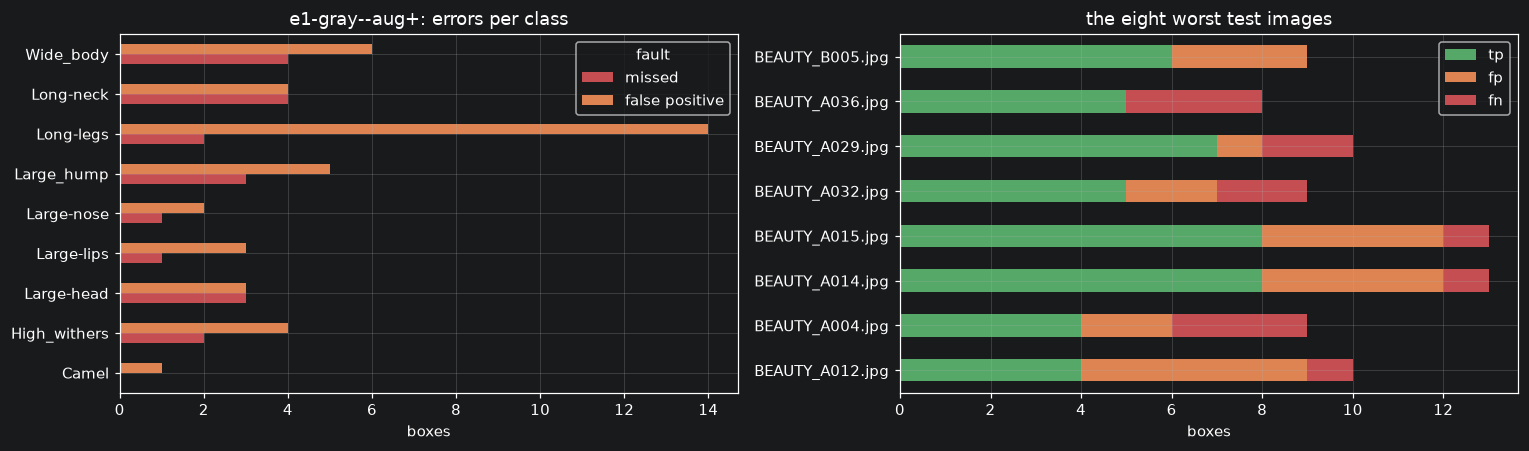

In [30]:
counts = errors.groupby(["cls", "fault"]).size().unstack(fill_value=0).reindex(canon).fillna(0)
for col in ("missed", "false positive"):
    if col not in counts:
        counts[col] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
counts[["missed", "false positive"]].plot(kind="barh", ax=axes[0], color=["#c44e52", "#dd8452"])
axes[0].set_title(f"{winner}: errors per class")
axes[0].set_xlabel("boxes")
axes[0].set_ylabel("")

ranked = images.assign(wrong=images.fp + images.fn).nlargest(8, "wrong").set_index("image")
ranked[["tp", "fp", "fn"]].plot(kind="barh", stacked=True, ax=axes[1],
                                color=["#55a868", "#dd8452", "#c44e52"])
axes[1].set_title("the eight worst test images")
axes[1].set_xlabel("boxes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. model selection

the highest-scoring run across every experiment in the project, written out with a version number so
the language component and the prototype load one fixed file.

In [31]:
best_tuned = compare.mAP50_95.max()
best_before = prev.mAP50_95.max()

if best_tuned >= best_before:
    final_run, final_score = winner, best_tuned
    src_ckpt = pathlib.Path(next(r["best"] for r in tested if r["run"] == winner))
    final_data = compare.loc[winner, "data"]
    final_imgsz = int(compare.loc[winner, "imgsz"])
else:
    final_run = prev.mAP50_95.idxmax()
    final_score = best_before
    src_ckpt = project / final_run / "weights" / "best.pt"
    final_data = prev.loc[final_run, "dataset"]
    prev_imgsz = prev.loc[final_run, "imgsz"] if "imgsz" in prev else None
    final_imgsz = int(prev_imgsz) if pd.notna(prev_imgsz) else 640

final = weights_dir / f"camel-det-{VERSION}.pt"
shutil.copy2(src_ckpt, final)

card = pd.Series({"model": final.name, "source_run": final_run, "dataset_version": VERSION,
                  "dataset": final_data, "imgsz": final_imgsz,
                  "test_mAP50_95": final_score, "saved_from": str(src_ckpt)})
card.to_frame("value").to_csv(results / "final_model.csv")

print(f"tuning best {best_tuned:.4f}   untuned best {best_before:.4f}")
print(f"final model: {final_run} -> {final}")
card

tuning best 0.4501   untuned best 0.4384
final model: e1-gray--aug+ -> E:\PycharmProjects\camel-beauty-assessor\weights\camel-det-v2.pt


model                                                camel-det-v2.pt
source_run                                             e1-gray--aug+
dataset_version                                                   v2
dataset                                                         gray
imgsz                                                            640
test_mAP50_95                                                 0.4501
saved_from         E:\PycharmProjects\camel-beauty-assessor\runs\...
dtype: object

## 8. mlops artifacts

In [32]:
for rec in tested:
    with mlflow.start_run(run_name=rec["run"] + "-test"):
        mlflow.log_params({k: rec[k] for k in
                           ("base", "variant", "data", "imgsz", "mosaic", "optimizer", "lr0", "weights")})
        mlflow.log_params({"epochs": epochs, "patience": patience, "batch": rec["batch"],
                           "dataset_version": VERSION})
        mlflow.log_metrics({k: rec[k] for k in ("mAP50", "mAP50_95", "precision", "recall")})
        for art in ("confusion_matrix_normalized.png", "PR_curve.png"):
            f = pathlib.Path(rec["val_dir"]) / art
            if f.exists():
                mlflow.log_artifact(str(f))

out = compare.reset_index()
out.insert(0, "logged_at", pd.Timestamp.now().isoformat(timespec="seconds"))
out.to_csv(results / "hyperparameter_tuning.csv", index=False)
pc.to_csv(results / "per_class_tuned.csv")
errors.to_csv(results / "error_analysis_tuned.csv", index=False)

print(f"{len(out)} rows written to {results / 'hyperparameter_tuning.csv'}")
out

40 rows written to E:\PycharmProjects\camel-beauty-assessor\results\v2\hyperparameter_tuning.csv


,logged_at,run,base,variant,data,imgsz,optimizer,lr0,minutes,mAP50,mAP50_95,precision,recall
0,2026-09-13T04:01:02,b1-rgb--ctrl,b1-rgb,ctrl,plain,640,auto,NaN,5.2,0.7672,0.4089,0.6276,0.8152
1,2026-09-13T04:01:02,e5-hires--ctrl,e5-hires,ctrl,plain,1280,auto,NaN,17.8,0.7536,0.4096,0.6956,0.7455
2,2026-09-13T04:01:02,e1-gray--ctrl,e1-gray,ctrl,gray,640,auto,NaN,2.9,0.6859,0.3828,0.6614,0.6567
3,2026-09-13T04:01:02,b3-aug-gray--ctrl,b3-aug-gray,ctrl,rot90-gray,640,auto,NaN,14.8,0.7091,0.3901,0.6826,0.6541
4,2026-09-13T04:01:02,e0-nomosaic--ctrl,e0-nomosaic,ctrl,plain,640,auto,NaN,7.0,0.7443,0.4176,0.7640,0.7029
5,2026-09-13T04:01:02,b1-rgb--sgd,b1-rgb,sgd,plain,640,SGD,0.0100,8.3,0.7529,0.4371,0.6941,0.7813
6,2026-09-13T04:01:02,e5-hires--sgd,e5-hires,sgd,plain,1280,SGD,0.0100,15.4,0.7486,0.4103,0.6687,0.7870
7,2026-09-13T04:01:02,e1-gray--sgd,e1-gray,sgd,gray,640,SGD,0.0100,4.5,0.7519,0.4242,0.7153,0.7198
8,2026-09-13T04:01:02,b3-aug-gray--sgd,b3-aug-gray,sgd,rot90-gray,640,SGD,0.0100,11.0,0.6889,0.3689,0.6600,0.7277
9,2026-09-13T04:01:02,e0-nomosaic--sgd,e0-nomosaic,sgd,plain,640,SGD,0.0100,6.5,0.7646,0.4473,0.7363,0.7612
